<a href="https://colab.research.google.com/github/hind190/Data-Mining-Project-/blob/main/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**[1] Problem**
The goal of this project is to analyze garment factory data to improve productivity.
We aim to predict productivity levels and discover patterns using data mining techniques.
This is important because improving productivity helps optimize operations and resource usage.

**Why Is This Important?**
Analyzing garment worker productivity is important because it provides a data-driven understanding of how real working conditions shape performance inside a factory. Instead of relying on assumptions or arbitrary target-setting, this project reveals the actual factors that influence productivity and how employee groups naturally behave. Its importance can be summarized through three clear contributions:


*   **Identifying the true drivers of productivity:** By examining attributes such as SMV, over_time, wip, idle_time, and team structure, the project uncovers which conditions most strongly affect a worker’s ability to meet targets—something factory management often cannot see directly.

*   **Exposing hidden performance patterns**: Clustering helps reveal natural groupings among workers and teams based on their operational behavior. These patterns highlight differences in workload, conditions, and efficiency that are not captured by a simple productivity label.
*   **Enabling fairer and more informed decision-making:** The insights gained allow for more realistic target setting, better resource allocation, and more equitable incentive systems, ultimately reducing the disconnect between management expectations and day-to-day factory realities.




#**[2] Data Mining Tasks**
The problem is formulated as both a classification and clustering task.




## **1.**   **Classification:**
Predict productivity class (Low, Medium, High)

**Classification Goal:**

 The objective of the classification task is to build a model capable of predicting a team’s productivity category (Low, Medium, or High) using the recorded factory features such as SMV, over_time, wip, incentive, idle_time, department, and team-related characteristics. Once trained, the model can be used to estimate whether a team is likely to meet or fall short of its productivity targets. This helps factory managers identify low-performing teams early, understand the conditions contributing to reduced productivity, and make more informed decisions to improve efficiency on the production floor.

---
## **2.**    **Clustering:**
For clustering, the model will group employees with similar productivity patterns. These clusters will be used to predict results for new employees based on the group they are most similar to, helping better manage employee performance.

**Clustering Goal:**

The goal of the clustering task is to group garment factory teams into meaningful clusters based on their productivity patterns and operational characteristics. By identifying teams that share similar working conditions such as overtime levels, idle time, workload, or incentive response the clustering process uncovers natural subgroups within the factory that are not visible through predefined labels. These clusters help management understand how different types of teams operate, enabling more targeted interventions, smarter resource allocation, and performance strategies tailored to each group’s specific needs.

#**[3] Data**
### **Dataset Overview**
Exploratory analysis in Phase 1 and Phase 2 focused on understanding the structure, distribution, and quality of the Garment Worker Productivity dataset. The dataset contains 1,197 observations and includes operational, temporal, and productivity related attributes, with actual_productivity serving as the main variable of interest.

## **Distribution and Summary Statistics**
Phase 1 and 2 analysis showed that several numerical features such as wip, over_time, idle_time, and smv—were skewed with noticeable extreme values. Histograms, boxplots, and five-number summaries confirmed that these variables had long right tails, indicating the need for normalization before clustering.

actual_productivity itself was concentrated mostly between 0.3 and 0.8, which helped guide later decisions for classification (discretizing it) and clustering.

## **Relationships Between Variables**
Scatter plots and correlation analysis highlighted several meaningful patterns:
*   smv and wip showed a positive relationship.


*   Higher idle_time was generally associated with lower productivity.

These observations supported the selection of relevant numeric features for clustering.

## **Summary**
The EDA revealed important characteristics of the dataset, including skewed distributions, meaningful correlations, and overall good data quality. These findings guided the preprocessing choices and feature selection strategies used in Phase 3.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("Preprocessed_dataset.csv")

In [3]:
print('Number of rows',df.shape[0])
print('Number of columns',df.shape[1])

Number of rows 1195
Number of columns 16


In [4]:
print(df.dtypes)

date                                object
quarter                             object
department                          object
day                                 object
team                                 int64
targeted_productivity              float64
smv                                float64
wip                                float64
over_time                            int64
incentive                            int64
idle_time                          float64
idle_men                             int64
no_of_style_change                   int64
no_of_workers                      float64
actual_productivity                float64
discretized_actual_productivity     object
dtype: object


In [5]:
df['categorized_label'] = df['actual_productivity']
num_bins = 3

df['Label'] = pd.cut(df['actual_productivity'], bins=num_bins, labels=['Low   ','Medium', 'High  '])
print('----------------------\nnum -- Class Labels --\n----------------------')
print(df['Label'])
print('-------------------------------------------------------')

print('-------------------------------------------------------')
print('Number of instances for each label:')
print('-------------------------------------------------------')
print('Class  -- Count ---------------------------------------')
print(df['Label'].value_counts())
print('-------------------------------------------------------')

----------------------
num -- Class Labels --
----------------------
0       High  
1       High  
2       Medium
3       Medium
4       Medium
         ...  
1190    Medium
1191    Medium
1192    Medium
1193    Low   
1194    Low   
Name: Label, Length: 1195, dtype: category
Categories (3, object): ['Low   ' < 'Medium' < 'High  ']
-------------------------------------------------------
-------------------------------------------------------
Number of instances for each label:
-------------------------------------------------------
Class  -- Count ---------------------------------------
Label
Medium    691
High      344
Low       160
Name: count, dtype: int64
-------------------------------------------------------


In [6]:
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,discretized_actual_productivity,categorized_label,Label
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725,High,0.940725,High
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500,High,0.886500,High
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,Medium,0.800570,Medium
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,Medium,0.800570,Medium
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382,Medium,0.800382,Medium


#**[4] Data Preprocessing**
### **Preprocessing from Phase 2**
Several preprocessing techniques were applied:

- Handling missing values (e.g., WIP column)
- Noise removal using IQR method
- Discretization of productivity into classes
- Normalization using MinMaxScaler

These steps improved data quality and prepared it for modeling.


---

### **Additional Preprocessing for Phase 3**

**For Classification**


*   Encoded categorical attributes (e.g., department, team) using Label Encoding.
*   Prepared the target variable for classification.

*   Created multiple train/test splits (90/10, 80/20, 70/30) for comparison.
**For Clustering**

*   Selected only numeric operational features for K-Means: smv, over_time, wip, incentive, idle_time.
*   Applied StandardScaler to normalize all clustering features, ensuring equal contribution to distance calculations and improving cluster separation.










In [11]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math


df = pd.read_csv("Preprocessed_dataset.csv")
df = pd.DataFrame(df)
Preprocessed_dataset = df.copy()

for col in ['department', 'day', 'quarter']:
    print(f"\nOriginal values in {col}:")
    print(df[col].unique())


Original values in department:
['sweing' 'finishing ' 'finishing']

Original values in day:
['Thursday' 'Saturday' 'Sunday' 'Monday' 'Tuesday' 'Wednesday']

Original values in quarter:
['Quarter1' 'Quarter2' 'Quarter3' 'Quarter4' 'Quarter5']


In [12]:
Preprocessed_dataset['department'] = Preprocessed_dataset['department'].replace({
    'sweing': 'sewing',
    'finishing ': 'finishing'
})

for col in ['department', 'day', 'quarter']:
    print(f"\nCleaned values in {col}:")
    print(Preprocessed_dataset[col].unique())


Cleaned values in department:
['sewing' 'finishing']

Cleaned values in day:
['Thursday' 'Saturday' 'Sunday' 'Monday' 'Tuesday' 'Wednesday']

Cleaned values in quarter:
['Quarter1' 'Quarter2' 'Quarter3' 'Quarter4' 'Quarter5']


In [14]:
Preprocessed_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
team,1195.0,6.422594,3.464294,1.000000,3.000000,6.000000,9.000000,12.000000
targeted_productivity,1195.0,0.730502,0.095461,0.350000,0.700000,0.750000,0.800000,0.800000
smv,1195.0,15.056603,10.948897,2.900000,3.940000,15.260000,23.975000,54.560000
wip,689.0,1191.171263,1839.732381,7.000000,776.000000,1039.000000,1251.000000,23122.000000
over_time,1195.0,4547.589958,3293.381720,0.000000,1440.000000,3960.000000,6915.000000,15120.000000
incentive,1195.0,38.242678,160.312926,0.000000,0.000000,0.000000,50.000000,3600.000000
idle_time,1195.0,0.731381,12.720362,0.000000,0.000000,0.000000,0.000000,300.000000
idle_men,1195.0,0.369874,3.271689,0.000000,0.000000,0.000000,0.000000,45.000000
no_of_style_change,1195.0,0.150628,0.428162,0.000000,0.000000,0.000000,0.000000,2.000000
no_of_workers,1195.0,34.574059,22.198835,2.000000,9.000000,34.000000,57.000000,89.000000


In [15]:
outlier_summary = {}
numeric_cols = [
    'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive',
    'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity']

for col in numeric_cols:
    Q1 = Preprocessed_dataset[col].quantile(0.25)
    Q3 = Preprocessed_dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (Preprocessed_dataset[col] < lower) | (Preprocessed_dataset[col] > upper)
    outlier_count = mask.sum()
    outlier_summary[col] = {'Q1':Q1, 'Q3':Q3, 'IQR':IQR, 'lower':lower, 'upper':upper, 'count':int(outlier_count)}
    print(f"\n{col}: {outlier_count} outliers")


targeted_productivity: 77 outliers

smv: 1 outliers

wip: 22 outliers

over_time: 0 outliers

incentive: 11 outliers

idle_time: 18 outliers

idle_men: 18 outliers

no_of_style_change: 147 outliers

no_of_workers: 0 outliers

actual_productivity: 54 outliers


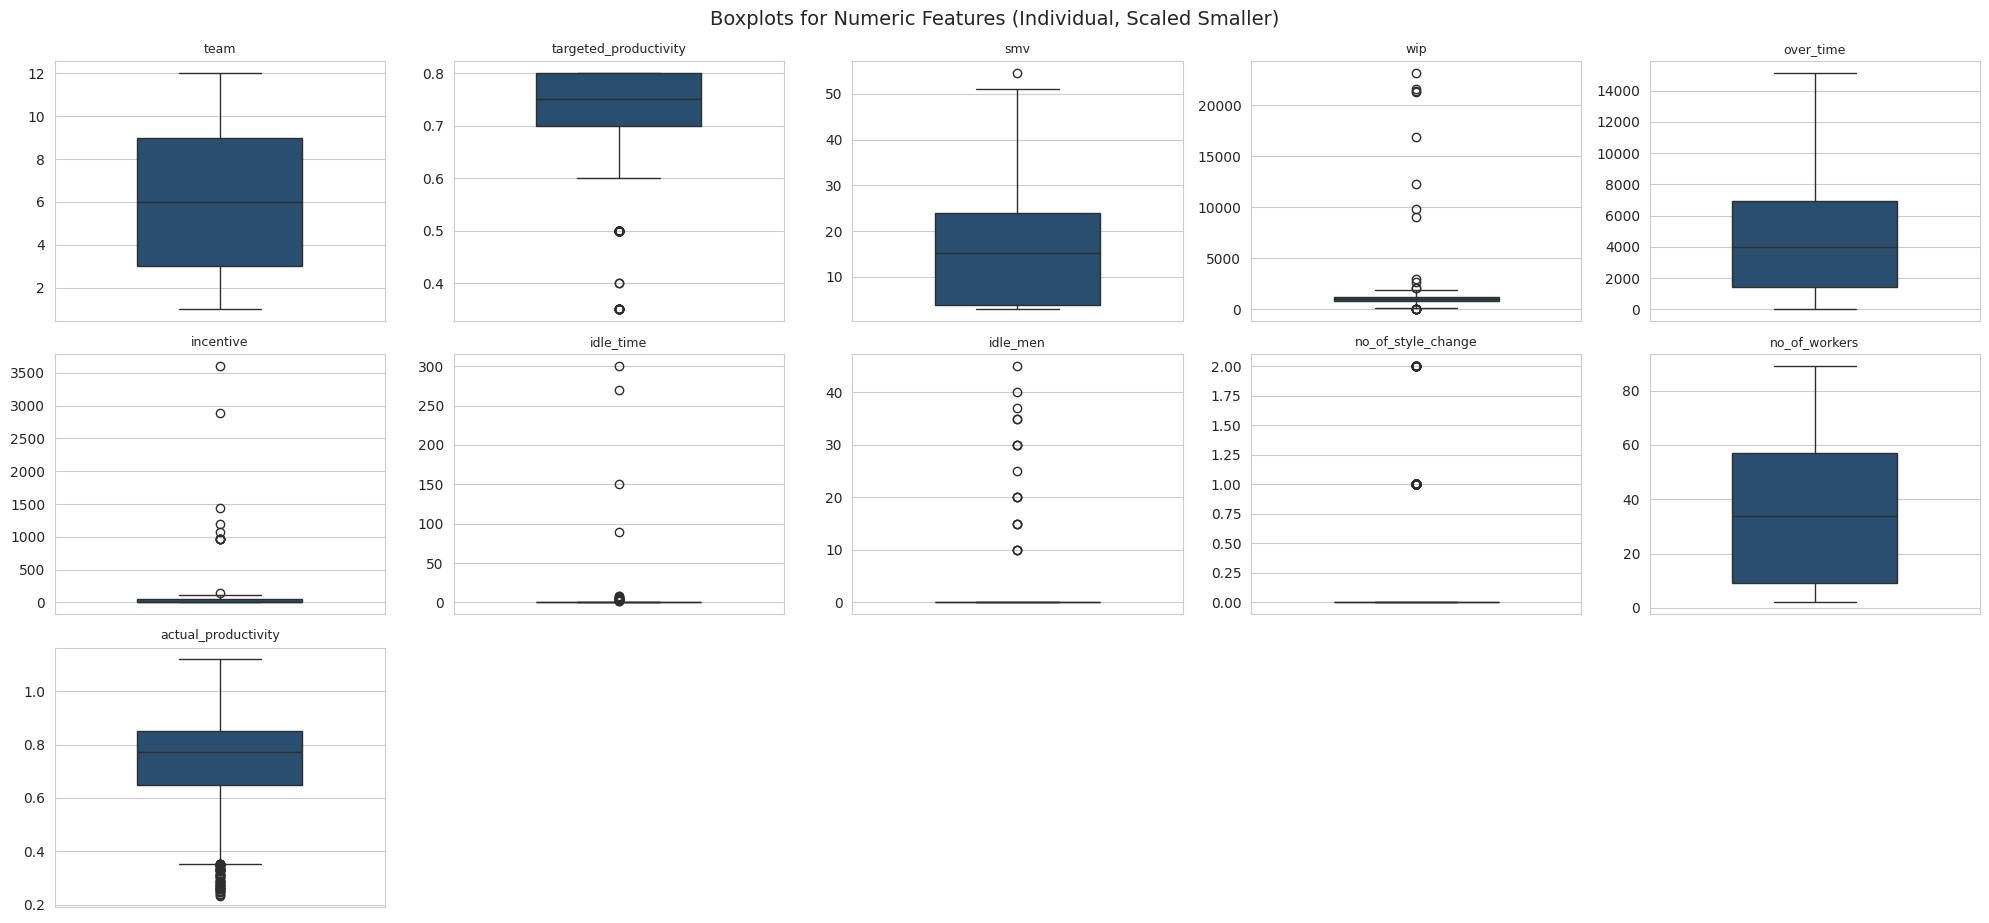

In [17]:
numeric_cols = df.select_dtypes(include='number').columns

cols_per_row = 5
rows = math.ceil(len(numeric_cols) / cols_per_row)

plt.figure(figsize=(4 * cols_per_row, 3 * rows))
sns.set_style('whitegrid')

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(y=df[col], color='#1f4e79', width=0.5)  # darker blue
    plt.title(col, fontsize=9)
    plt.xlabel('')
    plt.ylabel('')
    plt.tight_layout()

plt.suptitle('Boxplots for Numeric Features (Individual, Scaled Smaller)', fontsize=14, y=1.02)
plt.show()

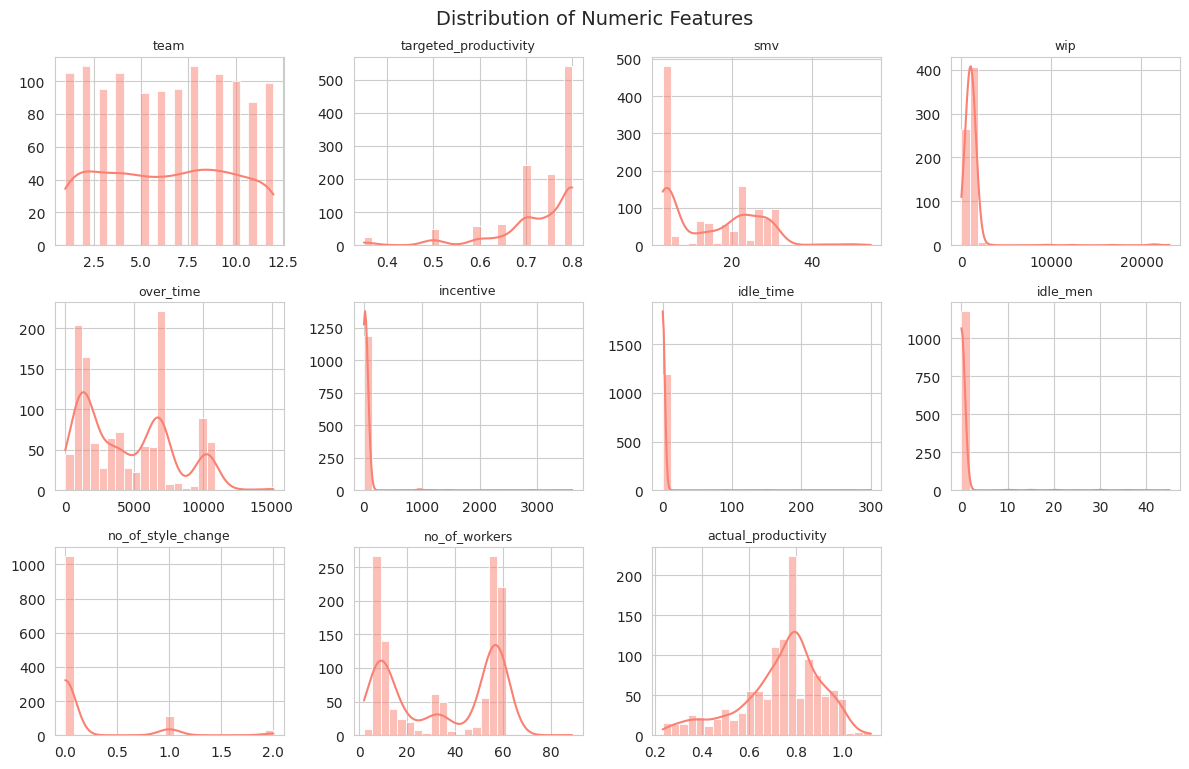

In [18]:
plots_per_row = 4
rows = 3
total_plots = len(numeric_cols)
sns.set_style('whitegrid')

plt.figure(figsize=(plots_per_row * 3, rows * 2.5))

for i, col in enumerate(numeric_cols[:plots_per_row * rows], 1):
    plt.subplot(rows, plots_per_row, i)
    sns.histplot(Preprocessed_dataset[col], kde=True, color='salmon', bins=25)
    plt.title(f'{col}', fontsize=9)
    plt.xlabel('')
    plt.ylabel('')
    plt.tight_layout()

plt.suptitle('Distribution of Numeric Features', fontsize=14, y=1.02)
plt.show()

wip    506
dtype: int64


/tmp/ipykernel_2203/1765706043.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index, y=missing.values, palette='viridis')


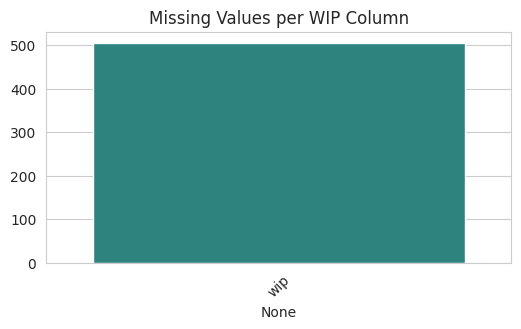

In [19]:
missing = Preprocessed_dataset.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

plt.figure(figsize=(6,3))
sns.barplot(x=missing.index, y=missing.values, palette='viridis')
plt.title('Missing Values per WIP Column')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_2203/3634434132.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='Missing Count', data=missing_by_dept, palette='Blues_r')


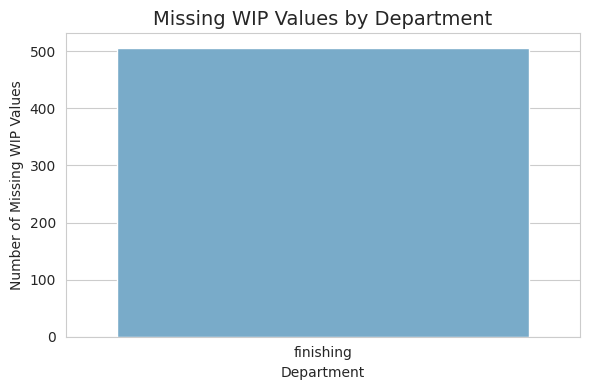

In [20]:
missing_wip = Preprocessed_dataset[Preprocessed_dataset['wip'].isnull()]

missing_by_dept = missing_wip['department'].value_counts().reset_index()
missing_by_dept.columns = ['Department', 'Missing Count']

plt.figure(figsize=(6,4))
sns.barplot(x='Department', y='Missing Count', data=missing_by_dept, palette='Blues_r')
plt.title('Missing WIP Values by Department', fontsize=14)
plt.xlabel('Department')
plt.ylabel('Number of Missing WIP Values')
plt.tight_layout()
plt.show()

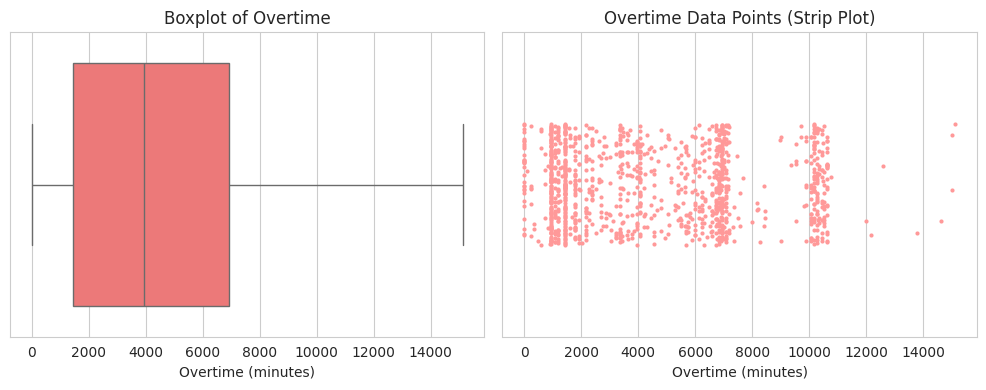

In [21]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=Preprocessed_dataset['over_time'], color='#ff6666')
plt.title('Boxplot of Overtime')
plt.xlabel('Overtime (minutes)')

plt.subplot(1,2,2)
sns.stripplot(x=Preprocessed_dataset['over_time'], color='#ff9999', jitter=0.2, size=3)
plt.title('Overtime Data Points (Strip Plot)')
plt.xlabel('Overtime (minutes)')

plt.tight_layout()
plt.show()

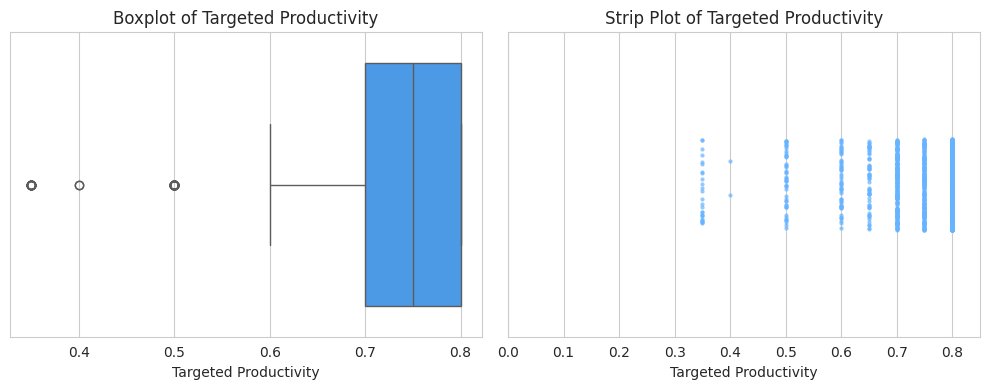

In [22]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=Preprocessed_dataset['targeted_productivity'], color='#3399ff')
plt.title('Boxplot of Targeted Productivity')
plt.xlabel('Targeted Productivity')

plt.subplot(1,2,2)
sns.stripplot(x=Preprocessed_dataset['targeted_productivity'], color='#66b3ff', size=3, jitter=0.15, alpha=0.7)
plt.title('Strip Plot of Targeted Productivity')
plt.xlabel('Targeted Productivity')
plt.xlim(0, 0.85)



plt.tight_layout()
plt.show()

/tmp/ipykernel_2203/1432464705.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


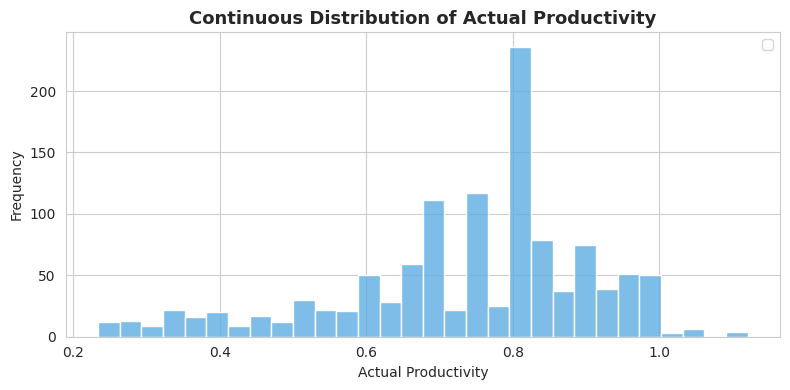

In [23]:
plt.figure(figsize=(8,4))

sns.histplot(Preprocessed_dataset['actual_productivity'], bins=30, color='#5dade2', alpha=0.8)

plt.title('Continuous Distribution of Actual Productivity', fontsize=13, fontweight='bold')
plt.xlabel('Actual Productivity')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_2203/1513061900.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ranges.index, y=ranges.values, palette='Blues_r')


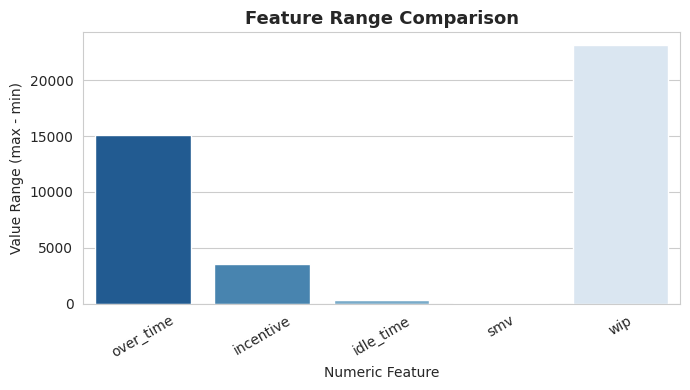

In [24]:
numeric_cols = ['over_time', 'incentive', 'idle_time', 'smv', 'wip']

ranges = Preprocessed_dataset[numeric_cols].max() - Preprocessed_dataset[numeric_cols].min()

plt.figure(figsize=(7,4))
sns.barplot(x=ranges.index, y=ranges.values, palette='Blues_r')
plt.title('Feature Range Comparison', fontsize=13, fontweight='bold')
plt.xlabel('Numeric Feature')
plt.ylabel('Value Range (max - min)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [26]:
min_before = Preprocessed_dataset['targeted_productivity'].min()
print(f"Lowest targeted_productivity before cleaning: {min_before}")

Preprocessed_dataset = Preprocessed_dataset[Preprocessed_dataset['targeted_productivity'] >= 0.1].reset_index(drop=True)
min_after = Preprocessed_dataset['targeted_productivity'].min()
print(f"Lowest targeted_productivity after cleaning: {min_after}")
removed_count = len(df) - len(Preprocessed_dataset)

print(f"\nNoise removal complete. {removed_count} data point removed.")

Lowest targeted_productivity before cleaning: 0.35
Lowest targeted_productivity after cleaning: 0.35

Noise removal complete. 0 data point removed.


In [27]:
max_before = Preprocessed_dataset['over_time'].max()
print(f"Highest over_time before cleaning: {max_before}")

Preprocessed_dataset = Preprocessed_dataset[Preprocessed_dataset['over_time'] <= 25000].reset_index(drop=True)

max_after = Preprocessed_dataset['over_time'].max()
print(f"Highest over_time after cleaning: {max_after}")

removed_count = len(df) - len(Preprocessed_dataset)
print(f"\nNoise removal complete. {removed_count} data points removed.")

Highest over_time before cleaning: 15120
Highest over_time after cleaning: 15120

Noise removal complete. 0 data points removed.


In [28]:
columns_to_normalize = ['smv', 'over_time', 'wip' , 'incentive' , 'idle_time']

data_to_normalize = Preprocessed_dataset[columns_to_normalize]
minmax_scaler = MinMaxScaler()
normalized_data_minmax = minmax_scaler.fit_transform(data_to_normalize)
Preprocessed_dataset[columns_to_normalize] = normalized_data_minmax
print("----- Min–Max normalized data for selected columns only ------")
print("")
print(Preprocessed_dataset.head())

----- Min–Max normalized data for selected columns only ------

       date   quarter department       day  team  targeted_productivity  \
0  1/1/2015  Quarter1     sewing  Thursday     8                   0.80   
1  1/1/2015  Quarter1  finishing  Thursday     1                   0.75   
2  1/1/2015  Quarter1     sewing  Thursday    11                   0.80   
3  1/1/2015  Quarter1     sewing  Thursday    12                   0.80   
4  1/1/2015  Quarter1     sewing  Thursday     6                   0.80   

        smv       wip  over_time  incentive  idle_time  idle_men  \
0  0.450252  0.047631   0.468254   0.027222        0.0         0   
1  0.020132       NaN   0.063492   0.000000        0.0         0   
2  0.164731  0.041575   0.242063   0.013889        0.0         0   
3  0.164731  0.041575   0.242063   0.013889        0.0         0   
4  0.445219  0.050314   0.126984   0.013889        0.0         0   

   no_of_style_change  no_of_workers  actual_productivity  \
0              

In [30]:
num_bins = 3
bin_labels = ['Low', 'Medium', 'High']

Preprocessed_dataset['discretized_actual_productivity'] = pd.cut(
    Preprocessed_dataset['actual_productivity'],
    bins=num_bins,
    labels=bin_labels,
    include_lowest=True
)

print('-------------------------------------------------------')
print('Discretization complete: actual_productivity → discretized_actual_productivity')
print('-------------------------------------------------------')
print('First few values:')
print(Preprocessed_dataset[['actual_productivity', 'discretized_actual_productivity']].head())
print('-------------------------------------------------------')
print('Number of instances for each label:')
print('-------------------------------------------------------')
print('Class  -- Count ---------------------------------------')
print(Preprocessed_dataset['discretized_actual_productivity'].value_counts())
print('-------------------------------------------------------')

-------------------------------------------------------
Discretization complete: actual_productivity → discretized_actual_productivity
-------------------------------------------------------
First few values:
   actual_productivity discretized_actual_productivity
0             0.940725                            High
1             0.886500                            High
2             0.800570                          Medium
3             0.800570                          Medium
4             0.800382                          Medium
-------------------------------------------------------
Number of instances for each label:
-------------------------------------------------------
Class  -- Count ---------------------------------------
discretized_actual_productivity
Medium    691
High      344
Low       160
Name: count, dtype: int64
-------------------------------------------------------


In [31]:
missing_before = Preprocessed_dataset['wip'].isna().sum()
print(f"Missing values in 'wip' before filling: {missing_before}")

Preprocessed_dataset['wip'] = Preprocessed_dataset['wip'].fillna(0)

missing_after = Preprocessed_dataset['wip'].isna().sum()
print(f"Missing values in 'wip' after filling: {missing_after}")

print("\nDataFrame after replacing missing 'wip' values with 0:")
print(Preprocessed_dataset[['wip']].head())

Missing values in 'wip' before filling: 506
Missing values in 'wip' after filling: 0

DataFrame after replacing missing 'wip' values with 0:
        wip
0  0.047631
1  0.000000
2  0.041575
3  0.041575
4  0.050314


In [32]:
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,discretized_actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725,High
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500,High
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,Medium
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,Medium
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382,Medium


In [33]:
Preprocessed_dataset.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,discretized_actual_productivity
0,1/1/2015,Quarter1,sewing,Thursday,8,0.80,0.450252,0.047631,0.468254,0.027222,0.0,0,0,59.0,0.940725,High
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,0.020132,0.000000,0.063492,0.000000,0.0,0,0,8.0,0.886500,High
2,1/1/2015,Quarter1,sewing,Thursday,11,0.80,0.164731,0.041575,0.242063,0.013889,0.0,0,0,30.5,0.800570,Medium
3,1/1/2015,Quarter1,sewing,Thursday,12,0.80,0.164731,0.041575,0.242063,0.013889,0.0,0,0,30.5,0.800570,Medium
4,1/1/2015,Quarter1,sewing,Thursday,6,0.80,0.445219,0.050314,0.126984,0.013889,0.0,0,0,56.0,0.800382,Medium


In [34]:
Preprocessed_dataset.to_csv("Preprocessed_dataset.csv", index=False)
print("Preprocessed dataset (with corrected department names) saved successfully.")

Preprocessed dataset (with corrected department names) saved successfully.


# **[5] Data Mining Technique**
## **Supervised Learning: Classification**

1. Decision Tree Classification using:
   - Gini index
   - Entropy

**How Implemented:**


*   Dataset split into training and testing subsets using train_test_split from sklearn.

*   Model built using DecisionTreeClassifier with Gini and Entropy as splitting criteria.
*   Performance evaluated using Confusion Matrix and visualized using plot_tree.

**Python Packages:**

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

### **Steps for Classification: Decision Tree**


**1. Preprocess Data:** Convert categorical features into numerical format(completed earlier) .

**2. Split Data:** Divide the dataset into training and testing sets (e.g., 70%-30%, 60%-40%, 80%-20%)

**3. Train Model:** Train the Decision Tree using Gini Index and Information Gain criteria.

**4. Evaluate:** Assess performance using Accuracy, Recall, Specificity, Precision, and Error Rate.

**5. Visualize:** Use plot_tree to interpret the Decision Tree structure.

**Splitting Criteria:**
We trained and evaluated the Decision Tree using two attribute selection measures:

- **Information Gain (Entropy):** criterion='entropy'
- **Gini Index:** criterion='gini'

The models were implemented using Python and Scikit-learn.

### **Decision Tree Classification using Gini Index**

In this section, we applied Decision Tree classification using the Gini index as the attribute selection measure.
The dataset was split into three different training and testing partitions:


*   90% training and 10% testing

*   80% training and 20% testing
*   70% training and 30% testing

For each split, the model was trained and evaluated using accuracy and confusion matrix.


---
## **Unsupervised Learning: Clustering**

2. K-Means Clustering using different values of K (2, 3, 4)

**How Implemented:**

*   Features standardized using StandardScaler. K-Means applied with different values of K

*   Evaluation conducted using:
    - Elbow Method to determine the optimal number of clusters.
    - Silhouette Score to assess compactness and separation of clusters.

**Python Packages:**
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

**Clustering Features:**
K-Means was applied only on numeric operational attributes after scaling:


*  smv
*  over_time
* wip
* incentive
* idle_time


 **Evaluation Methods:**


1.   **Silhouette Score:**
Measures cluster cohesion and separation, the higher the value, the better.
2.   **Elbow Method:**
Uses Within-Cluster Sum of Squares (WCSS / inertia) to identify where additional clusters stop providing significant improvement.

**Procedure:**


*   K-Means was run for multiple values of ( K ) (3, 4, 5, 6) to generate WCSS and Silhouette curves.

*   Based on the elbow and silhouette trends, four candidate K values were selected for deeper analysis.
*   For each selected K, we evaluated:
    - WCSS
    - Silhouette Coefficient
    - Cluster centers
    - PCA-based cluster visualization

These methods allowed us to determine the most meaningful cluster structure that represents productivity behavior in the dataset.

**Integrated Value:**

By combining classification and clustering techniques, we gain both predictive power and deeper understanding:


*   **Classification** allows for predicting individual performance, enabling factory managers to identify productivity levels.
*   **Clustering** reveals natural groups of workers with similar operational patterns to design targeted improvements for each group.


Together, these methods offer actionable insights that support better decision-making and enhanced productivity outcomes.

# **[6] Evaluation and Comparison**
This section presents the evaluation results for both **classification** (Decision Trees) and **clustering** (K-Means).
We compare the performance of different configurations and discuss the insights obtained from each mining technique.


# **Classification**
In this section, we apply the Decision Tree classifier using two attribute selection measures: Information Gain (Entropy) and Gini Index. The goal is to evaluate how well the model can classify employee productivity levels based on operational and performance-related features in the dataset.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# **Feature Selection:**
Feature selection is the process of identifying and selecting the most relevant features (independent variables) for the model. For the garment productivity classification task, we use all the available features except for the target variable (discretized_actual_productivity) and the date.

In [40]:
features = Preprocessed_dataset.drop(columns=[
    'date', 'actual_productivity', 'discretized_actual_productivity'])

X = pd.get_dummies(
    features,
    columns=['quarter', 'department', 'day'],
    drop_first=True)

y = Preprocessed_dataset['discretized_actual_productivity']

# **Gini index with 10% for testing and 90% for training**
In decision tree learning, the Gini index measures how impure or mixed a node is. The goal at each split is to choose the feature and threshold that minimize Gini impurity, creating child nodes that are more homogeneous than the parent node.

# **Splitting Data**
To evaluate the performance of the classifier, we need to divide the dataset into a training set (used to train the model) and a test set (used to evaluate the model's performance on unseen data) here we chose 10% of the data for testing, while 90% is used for training.

In [41]:
# 90/10 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.9, random_state=1, stratify=y
)

# Train the model (Gini)
model_90_gini = DecisionTreeClassifier(random_state=1)
model_90_gini.fit(X_train, y_train)


DecisionTreeClassifier(random_state=1)

 **In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.**

In [42]:
clf=DecisionTreeClassifier()
clf=clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)

# **Confusion Matrix:**

[[23  1 11]
 [ 2  8  6]
 [ 3  3 63]]


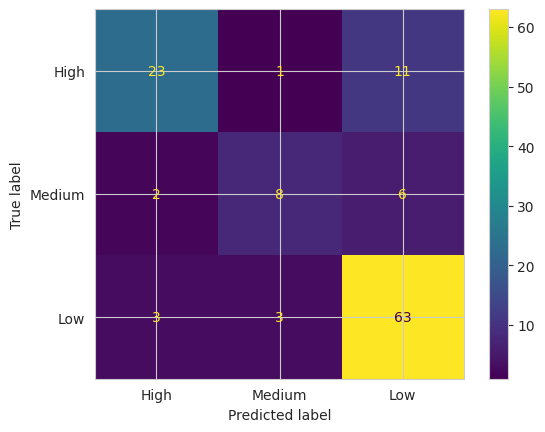

In [43]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

cn = Preprocessed_dataset['discretized_actual_productivity'].unique()

disp = ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, display_labels=cn
)

The confusion matrix shows the model’s performance across the three productivity categories: High, Medium, and Low. Each row represents the actual class, while each column represents the predicted class.

*   For the High class: 23 instances were correctly classified as High. Only 1 instance was misclassified as Medium, and 11 instances were misclassified as Low.

*   For the Medium class: 8 instances were correctly classified as Medium. Meanwhile, 2 instances were incorrectly predicted as High, and 6 were predicted as Low.

*   For the Low class: 63 instances were correctly classified as Low. A small number of cases were misclassified: 3 as High and 3 as Medium.




# **Decision Tree:**

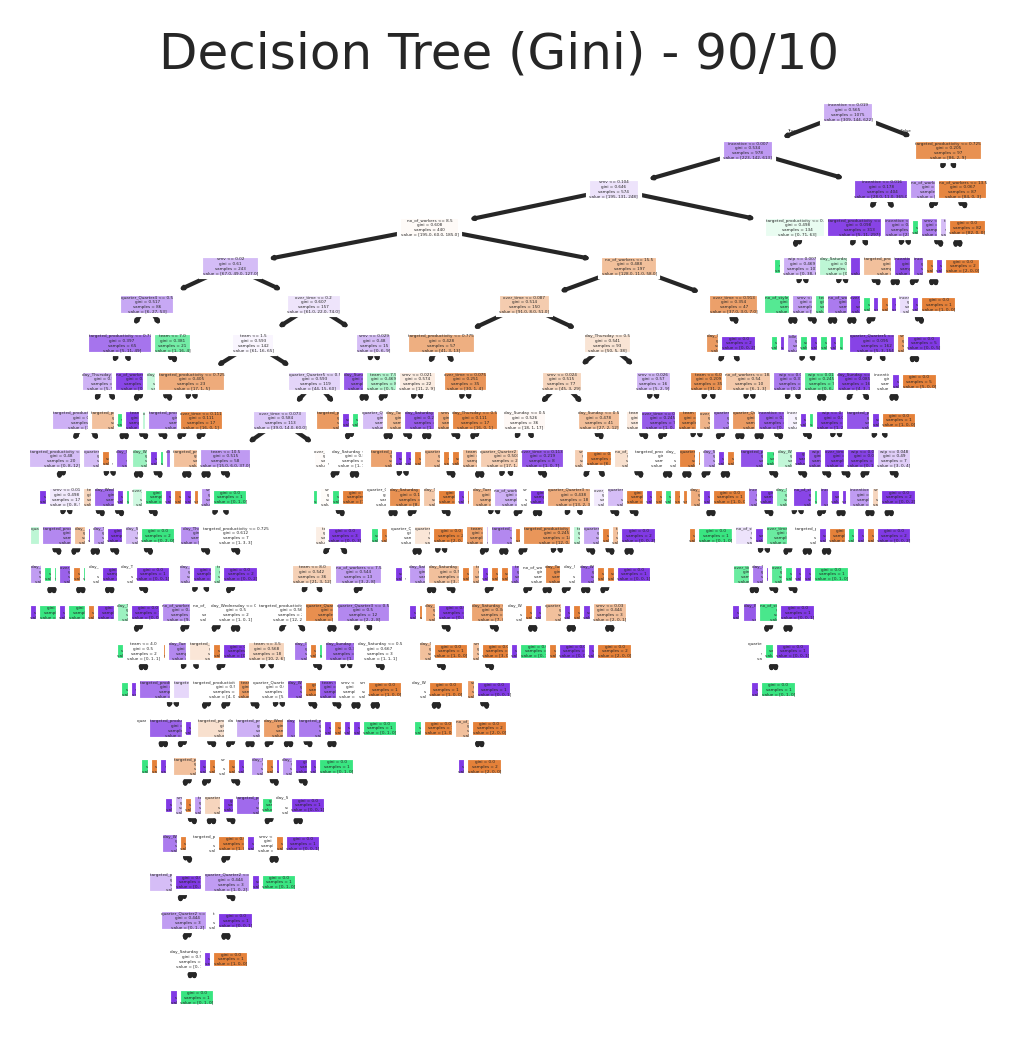

In [44]:

from sklearn import tree
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4), dpi=300)

tree.plot_tree(
    model_90_gini,
    ax=ax,
    filled=True,
    feature_names=X.columns
)

plt.title("Decision Tree (Gini) - 90/10 ")
plt.show()

In this decision tree, the model begins by splitting on the production features that provide the strongest separation between productivity levels, such as WIP or targeted productivity. These attributes are chosen first because they reduce Gini impurity the most, helping the model distinguish early between Low, Medium, and High productivity groups.

As the tree expands, additional features including SMV, overtime, incentives, and department create further splits that refine the classification. Each branch leads to increasingly homogeneous subsets, and the leaves represent the model’s final predictions for each productivity category.

# **Model Evaluation**

In [46]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print("confusion matrix : \n",cm)

accuracy = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

error_rate = 1 - accuracy
print("Error Rate:", error_rate)


TP = cm[1, 1]
TN = cm[0, 0] + cm[0, 2] + cm[2, 0] + cm[2, 2]
FP = cm[0, 1] + cm[2, 1]
FN = cm[1, 0] + cm[1, 2]


sensitivity = TP / (TP + FN)
print("Sensitivity:", sensitivity)


specificity = TN / (TN + FP)
print("Specificity:", specificity)


precision = TP / (TP + FP)
print("Precision:", precision)

confusion matrix : 
 [[23  1 11]
 [ 2  8  6]
 [ 3  3 63]]
Accuracy: 0.7833333333333333
Error Rate: 0.21666666666666667
Sensitivity: 0.5
Specificity: 0.9615384615384616
Precision: 0.6666666666666666




* **Accuracy:** Measures the proportion of correct predictions out of all predictions. Here, the model achieved an accuracy of 78.3%, meaning it correctly classified a large majority of the productivity instances.

*   **Error Rate:** Represents the percentage of incorrect predictions. In this case, the error rate is approximately 21.7%, indicating that about one-fifth of the predictions were misclassified.
*   **Sensitivity (Recall):** Indicates the proportion of true positives correctly identified for the selected class (Medium). The sensitivity is 50%, showing that the model detects only half of the Medium productivity cases correctly.
*   **Specificity:** Measures the proportion of true negatives correctly identified. With a specificity of 96.1%, the model is highly effective at recognizing cases that do not belong to the Medium class.

*  **Precision:** Refers to the accuracy of positive predictions for the Medium class. Here, the precision is 66.7%, meaning that about two-thirds of predictions labeled as Medium are actually correct.








---


# **Outcomes**
*   The model achieves a strong overall accuracy of 78.3%, correctly classifying most productivity levels.

*   The high specificity (96.1%) indicates the model is very good at identifying non-Medium cases. This reflects difficulty in capturing patterns specific to this category.
*   However, the sensitivity (50%) reveals difficulty detecting Medium productivity instances.

*   The precision (66.7%) shows that when the model does predict Medium, it is correct most of the time.



---
## **Gini index with 20% for testing and 80% for training**

**Splitting Data**

To evaluate the performance of the classifier, we need to divide the dataset into a training set (used to train the model) and a test set (used to evaluate the model's performance on unseen data) here we chose 20% of the data for testing, while 80% is used for training.





In [47]:
# 80/20 split
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, train_size=0.8, random_state=1, stratify=y
)

model_80_gini = DecisionTreeClassifier(random_state=1)
model_80_gini.fit(X_train_80, y_train_80)

y_pred_80 = model_80_gini.predict(X_test_20)

**Confusion Matrix:**

Confusion Matrix (80/20 Split):
 [[ 50   0  19]
 [  4  19   9]
 [ 20   7 111]]


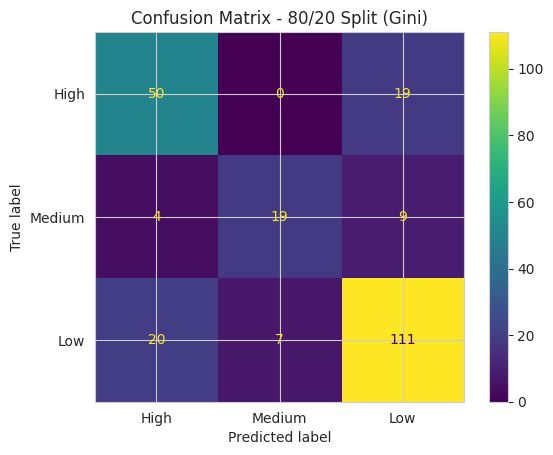

In [48]:
cm_80 = confusion_matrix(y_test_20, y_pred_80)
print("Confusion Matrix (80/20 Split):\n", cm_80)

disp_80 = ConfusionMatrixDisplay(confusion_matrix=cm_80, display_labels=y.unique())
disp_80.plot(cmap='viridis')
plt.title("Confusion Matrix - 80/20 Split (Gini)")
plt.show()

The confusion matrix below summarizes the model’s performance across the three productivity categories (High, Medium, Low).


*  ** High category:** The model correctly classified 50 instances as High. However, 19 High samples were misclassified as Low, and 0 were predicted as Medium.

*   **Medium category:** The model correctly identified 19 Medium samples. Still, 4 Medium instances were incorrectly labeled as High, and 9 as Low.
*   **Low category:** The model showed strong performance for the Low class, correctly predicting 111 samples. Yet, 20 Low instances were misclassified as High, and 7 as Medium.

Overall, the matrix shows that the model performs well, particularly in predicting the Low category, while most misclassifications occur between neighboring levels of productivity. This indicates reasonable classification behavior but also suggests opportunities to improve boundary separation between the classes.





**Decision Tree:**

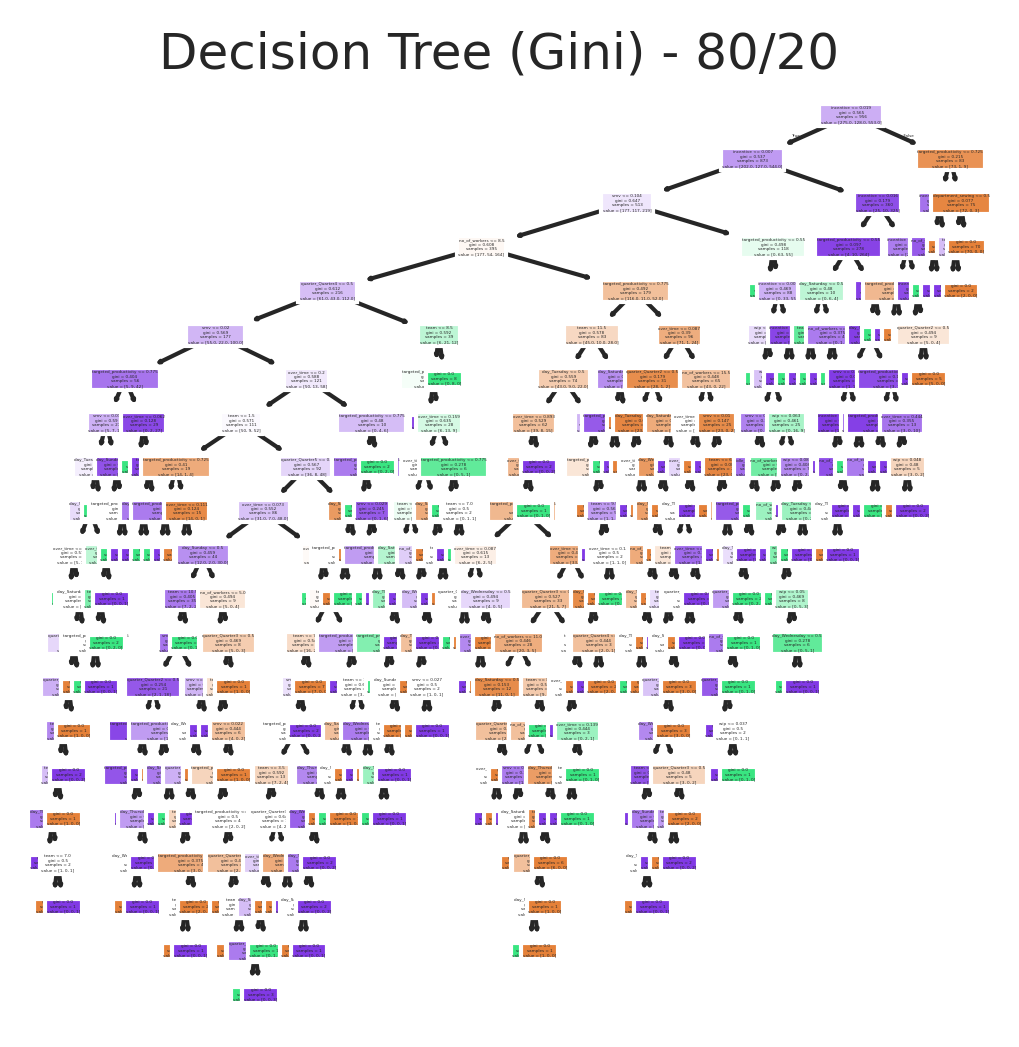

In [49]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4), dpi=300)

tree.plot_tree(
    model_80_gini,
    ax=ax,
    filled=True,
    feature_names=X.columns
)

plt.title("Decision Tree (Gini) - 80/20 ")
plt.show()

The decision tree for the 80/20 split contains a large number of internal nodes and leaf nodes, indicating that the model has created many detailed decision rules to separate the classes. Important features such as wip, targeted_productivity, and smv appear frequently at higher-level nodes, showing that they play a major role in the classification process.

However, the high number of leaf nodes and the overall depth of the tree suggest that the model may be overfitting, capturing noise in addition to meaningful patterns.

## **Model Evaluation**

In [50]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_20, y_pred_80)
print("Confusion Matrix:\n", cm)

accuracy = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

error_rate = 1 - accuracy
print("Error Rate:", error_rate)

TP = cm[1, 1]

TN = cm[0, 0] + cm[0, 2] + cm[2, 0] + cm[2, 2]


FP = cm[0, 1] + cm[2, 1]

FN = cm[1, 0] + cm[1, 2]

sensitivity = TP / (TP + FN)
print("Sensitivity (Recall):", sensitivity)

specificity = TN / (TN + FP)
print("Specificity:", specificity)

precision = TP / (TP + FP)
print("Precision:", precision)

Confusion Matrix:
 [[ 50   0  19]
 [  4  19   9]
 [ 20   7 111]]
Accuracy: 0.7833333333333333
Error Rate: 0.21666666666666667
Sensitivity (Recall): 0.59375
Specificity: 0.966183574879227
Precision: 0.7307692307692307




*   **Accuracy:** Represents the overall correctness of the model. With an accuracy of 77.5%, the classifier correctly predicts about three-quarters of all instances.

*   **Error Rate:** Indicates the proportion of incorrect predictions. The error rate is 22.5%, meaning a little over one-fifth of the predictions were wrong.

*   **Sensitivity (True Positive Rate):** Measures how well the model identifies actual Medium cases. At 59.4%, the model detects slightly more than half of the true Medium instances.

*   **Specificity (True Negative Rate):** Evaluates how well the model recognizes samples that are not Medium. With a specificity of 96.6%, the model performs very strongly in distinguishing non-Medium cases.


*   **Precision (Positive Predictive Value):** Shows how many of the samples predicted as Medium were actually correct. The precision of 73.1% indicates that most Medium predictions were accurate.


---
**Outcomes**


*   The model achieves a strong overall accuracy, correctly predicting about 77.5% of all instances.

*   The sensitivity, at 59.4%, shows that the model is moderately effective at identifying Medium cases, though it misses a noticeable portion of them.
*   LSpecificity is very high at 96.6%, demonstrating that the model excels at correctly recognizing non-Medium cases.


*   Precision, at 73.1%, indicates a good level of confidence in the correctness of the model’s Medium predictions.


---








# **Analysis of Metrics**
**Accuracy:** Accuracy is consistent across all splits at 78.3%, indicating stable model performance regardless of the train–test ratio.

**Error Rate:** The error rate is also stable at 21.6%, matching the accuracy levels and showing similar misclassification behavior across all splits.

**Sensitivity (Recall):** Sensitivity varies slightly:

*   The 70/30 split achieves the highest recall (62.5%).
*   The 90/10 and 80/20 splits show lower recall (56.25%). This indicates the model detects Medium cases slightly better with a larger test set.

**Specificity:** Specificity remains high overall (from 92.9% to 98%), showing strong ability to correctly identify non-Medium cases. The 80/20 split delivers the highest specificity (98.06%).

**Precision:** Precision ranges between 57.7% and 81%, showing moderate correctness of Medium predictions. The 80/20 split achieves the highest precision (81%).

## **Gini index with 30% for testing and 70% for training**

**Splitting Data**

To evaluate the performance of the classifier, we need to divide the dataset into a training set (used to train the model) and a test set (used to evaluate the model's performance on unseen data) here we chose 30% of the data for testing, while 70% is used for training.

In [51]:
# 70/30 split
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, train_size=0.7, random_state=1, stratify=y
)

model_70_gini = DecisionTreeClassifier(random_state=1)
model_70_gini.fit(X_train_70, y_train_70)

y_pred_70 = model_70_gini.predict(X_test_30)

**Confusion Matrix:**

Confusion Matrix (70/30 Split):
 [[ 72   5  26]
 [  4  25  19]
 [ 22  15 171]]


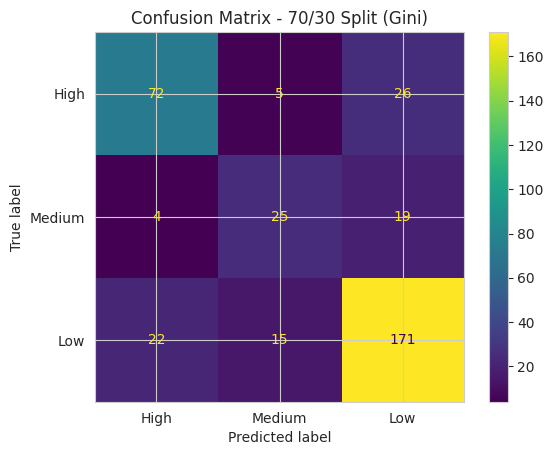

In [52]:
cm_70 = confusion_matrix(y_test_30, y_pred_70)
print("Confusion Matrix (70/30 Split):\n", cm_70)

disp_70 = ConfusionMatrixDisplay(confusion_matrix=cm_70, display_labels=y.unique())
disp_70.plot(cmap='viridis')
plt.title("Confusion Matrix - 70/30 Split (Gini)")
plt.show()

The confusion matrix provides a clear summary of how well the model distinguishes between the three productivity categories.


*   **High class:** The model correctly classified 72 High instances, while 5 were misclassified as Medium and 26 as Low, indicating that some High cases are being confused with lower productivity levels.

*  **Medium class:** 25 Medium instances were correctly identified, whereas 4 were incorrectly labeled as High and 19 as Low. This shows that the Medium class experiences notable spillover into the Low class.
*   **Low class:** The model performs strongly here, correctly predicting 171 Low instances. However, 22 were misclassified as High and 15 as Medium.

Overall, the matrix shows that the model is most reliable at identifying Low cases, with reasonable performance on the High class. The Medium class remains the most challenging category, with a noticeable amount of confusion between Medium and Low labels.


**Decision Tree:**

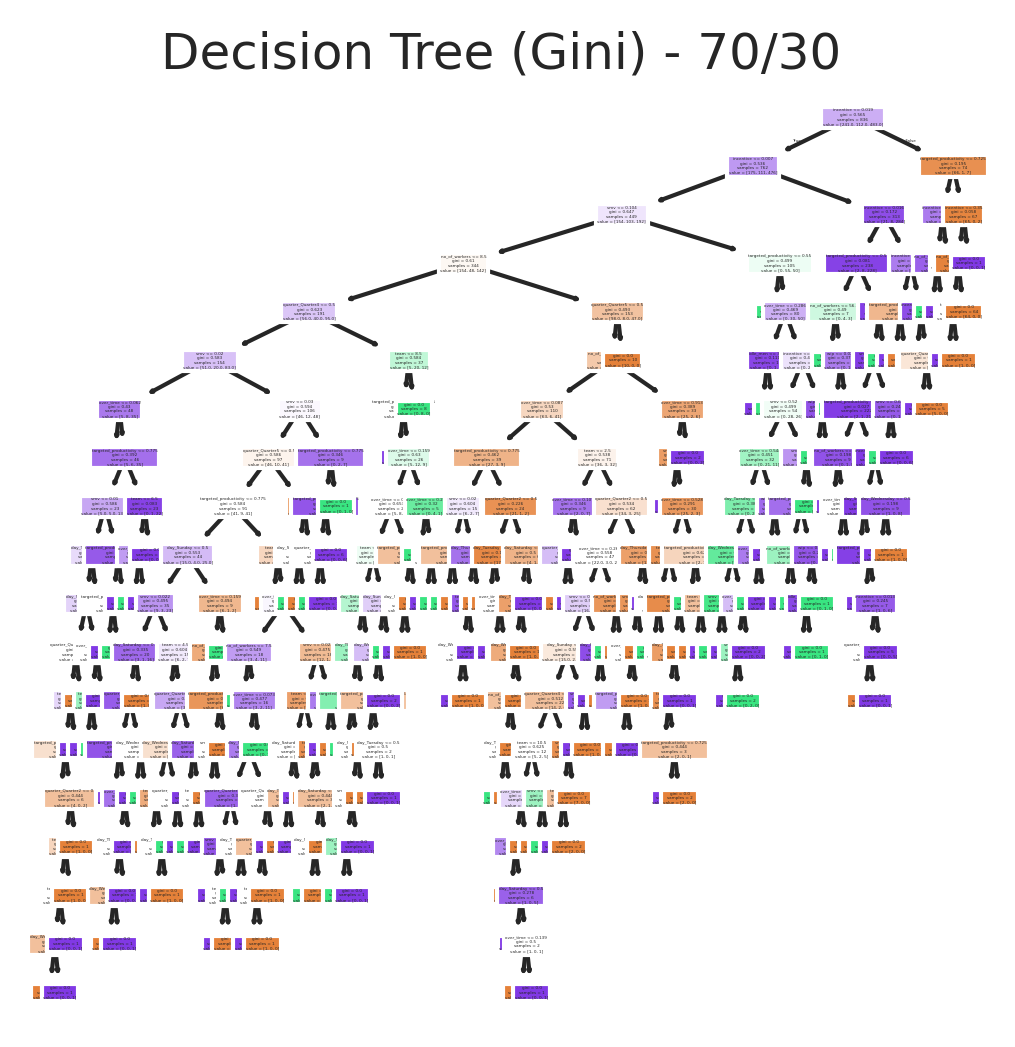

In [53]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4), dpi=300)

tree.plot_tree(
    model_70_gini,
    ax=ax,
    filled=True,
    feature_names=X.columns
)

plt.title("Decision Tree (Gini) - 70/30 ")
plt.show()

The decision tree generated using the 70/30 split is large and highly branched, showing that the model performs many sequential decisions before reaching a final prediction. The tree contains numerous internal nodes, each splitting the data based on key features such as wip, incentive, and day_Thursday, indicating that these variables play an important role in distinguishing between High, Medium, and Low productivity levels.

As the tree expands downward, the branches become more specific, gradually separating overlapping cases into clearer groups. This results in many leaf nodes, each representing a final class prediction based on the path of decisions above it. The presence of a high number of leaf nodes reflects the model’s attempt to capture subtle patterns in the dataset.

Overall, the depth and complexity of the tree suggest that the model fits closely to the training data. While this can help capture nuanced relationships, it may also indicate a risk of overfitting, especially given how detailed and fragmented some branches become.

**Model Evaluation**

In [54]:

from sklearn import metrics
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_30, y_pred_70)
print("Confusion Matrix:\n", cm)

accuracy = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

error_rate = 1 - accuracy
print("Error Rate:", error_rate)

TP = cm[1, 1]

TN = cm[0, 0] + cm[0, 2] + cm[2, 0] + cm[2, 2]

FP = cm[0, 1] + cm[2, 1]

FN = cm[1, 0] + cm[1, 2]

sensitivity = TP / (TP + FN)
print("Sensitivity (Recall):", sensitivity)

specificity = TN / (TN + FP)
print("Specificity:", specificity)

precision = TP / (TP + FP)
print("Precision:", precision)


Confusion Matrix:
 [[ 72   5  26]
 [  4  25  19]
 [ 22  15 171]]
Accuracy: 0.7833333333333333
Error Rate: 0.21666666666666667
Sensitivity (Recall): 0.5208333333333334
Specificity: 0.9356913183279743
Precision: 0.5555555555555556




*   **Accuracy:** Reflects the overall correctness of the model, calculated as the ratio of correct predictions to total predictions. In this case, the model’s accuracy is approximately 77.5%, indicating a generally reliable performance.

*   **Error Rate:** Represents the proportion of incorrect predictions, computed as 1 − Accuracy. Here, the error rate is around 22.5%, meaning roughly one in five predictions is incorrect.

*   **Sensitivity (True Positive Rate):** Measures the proportion of actual positive cases correctly identified by the model. In this scenario, sensitivity is approximately 52.1%, showing that the model struggles to identify Medium cases accurately.

*   **Specificity (True Negative Rate):** Reflects the model’s ability to correctly identify negative cases. The specificity is around 93.6%, indicating strong performance in distinguishing non-Medium cases.

*   **Precision (Positive Predictive Value):** Represents the proportion of correctly predicted positive cases among all predicted positives. Here, the precision is about 55.6%, suggesting that just over half of the model’s Medium predictions are correct.


**Outcomes**


*   The model achieves a moderate overall accuracy of 77.5%, meaning it correctly predicts the class label for a substantial portion of cases. This indicates that the classifier performs reliably on unseen data.

*  The sensitivity (52.1%) shows that the model is less effective at correctly identifying positive cases (the Medium class). This reflects difficulty in capturing patterns specific to this category.
*  In contrast, the specificity is strong at 93.6%, highlighting the model’s strong ability to correctly recognize negative cases. This means that when the model predicts a sample is not Medium, it is usually correct.


*   The precision (55.6%) suggests a moderate level of confidence in the model’s positive predictions, as slightly more than half of the samples predicted as Medium were truly Medium.



---
### **Evaluate the models of Gini Index:**



| Split                  | Accuracy | Error Rate | Sensitivity | Specificity | Precision |
|----------------------|----------|------------|-------------|-------------|-----------|
| 90% Train, 10% Test  | 0.7833   | 0.2167     | 0.5000      | 0.9615      | 0.6667    |
| 80% Train, 20% Test  | 0.7750   | 0.2250     | 0.5938      | 0.9357      | 0.5556    |
| 70% Train, 30% Test  | 0.7750   | 0.2250     | 0.5208      | 0.9357      | 0.5556    |




### **Analysis of Metrics**


*   Accuracy: The accuracy across the three splits is consistent, ranging from 77–78%, indicating stable model performance. The 90/10 split has the highest accuracy (78.33%), likely due to more training data improving the model's fit.
*   Error Rate: Error rates fall between 21–22%, inversely mirroring accuracy. The 90/10 split has the lowest error rate (21.67%), again reflecting its higher accuracy.
* Sensitivity (Recall): Sensitivity varies more noticeably across splits: 80/20 split achieves the highest sensitivity (59.38%), meaning it identifies positive (Medium) cases better. The 90/10 split shows the lowest sensitivity (50%), indicating more missed positive cases. This suggests that testing on a larger set (20%) slightly improves the model’s recall for this dataset.
* Specificity: Specificity is strong across all splits, ranging from 93% to 96%. The 90/10 split delivers the highest specificity (96.15%), showing strong ability to correctly identify negative cases.
* Precision: Precision ranges from 55% to 66%. The 90/10 split provides the highest precision (66.67%), suggesting better correctness in positive predictions.






### **Summary**

The 90/10 split gives the strongest overall performance, showing the best accuracy, lowest error rate, highest specificity, and highest precision. The 80/20 split performs best in sensitivity, meaning it is better at detecting positive cases than the other splits. The 70/30 split performs similarly to 80/20, though slightly weaker in sensitivity and equal in precision.

All in all, based on the balance of metrics, the 90/10 split is the most reliable model, especially if accuracy, precision, and specificity are the primary goals. If the priority is to maximize sensitivity (catching positive cases), the 80/20 split offers a better trade-off.


---
## **Entropy**
Entropy measures the uncertainty or disorder in data. It helps decide the best way to split data, aiming to reduce uncertainty and improve classification accuracy.

## **Entropy with 10% for testing and 90% for training**
### **Splitting Data**
The data is split into 90% for training and 10% for testing. A decision tree model is trained using entropy for splitting, and then predictions are made on the test data to assess the model's performance.


In [55]:
#90/10 split
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X, y,
    train_size=0.9,
    random_state=1,
    stratify=y
)
# Train the model (Entropy)
model_90_ent = DecisionTreeClassifier(criterion="entropy", random_state=1)
model_90_ent.fit(X_train_90, y_train_90)

y_pred_90_ent = model_90_ent.predict(X_test_10)

### **Confusion Matrix:**

Confusion Matrix (90/10 Split):
 [[24  3  8]
 [ 2  9  5]
 [ 2  3 64]]


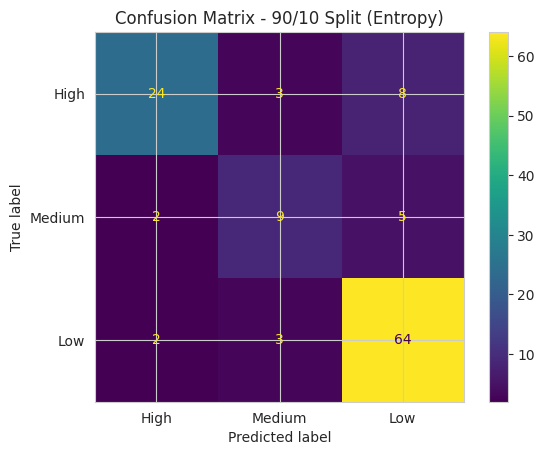

In [56]:
# Confusion matrix for 90/10
cm_90 = confusion_matrix(y_test_10,y_pred_90_ent )
print("Confusion Matrix (90/10 Split):\n", cm_90)

disp_90 = ConfusionMatrixDisplay(confusion_matrix=cm_90, display_labels=y.unique())
disp_90.plot(cmap='viridis')
plt.title("Confusion Matrix - 90/10 Split (Entropy)")
plt.show()



*   **High category:** The model correctly classified 24 instances as High. However, 8 High samples were misclassified as Low, and 3 were predicted as Medium.

*   **Medium category:** The model correctly identified 9 Medium samples. Still, 2 Medium instances were incorrectly labeled as High, and 5 as Low.

*   **Low category:** The model showed strong performance for the Low class, correctly predicting 64 instances. Yet, 2 Low samples were misclassified as High, and 3 as Medium.


Overall, the confusion matrix indicates that the model performs well overall, especially in predicting the Low category. Most misclassifications occur between neighboring categories (High–Medium, Medium–Low), which is expected due to the similarity between productivity levels. This suggests that the model captures the overall structure of the data but may still benefit from improved separation between adjacent classes.





### **Decision Tree**

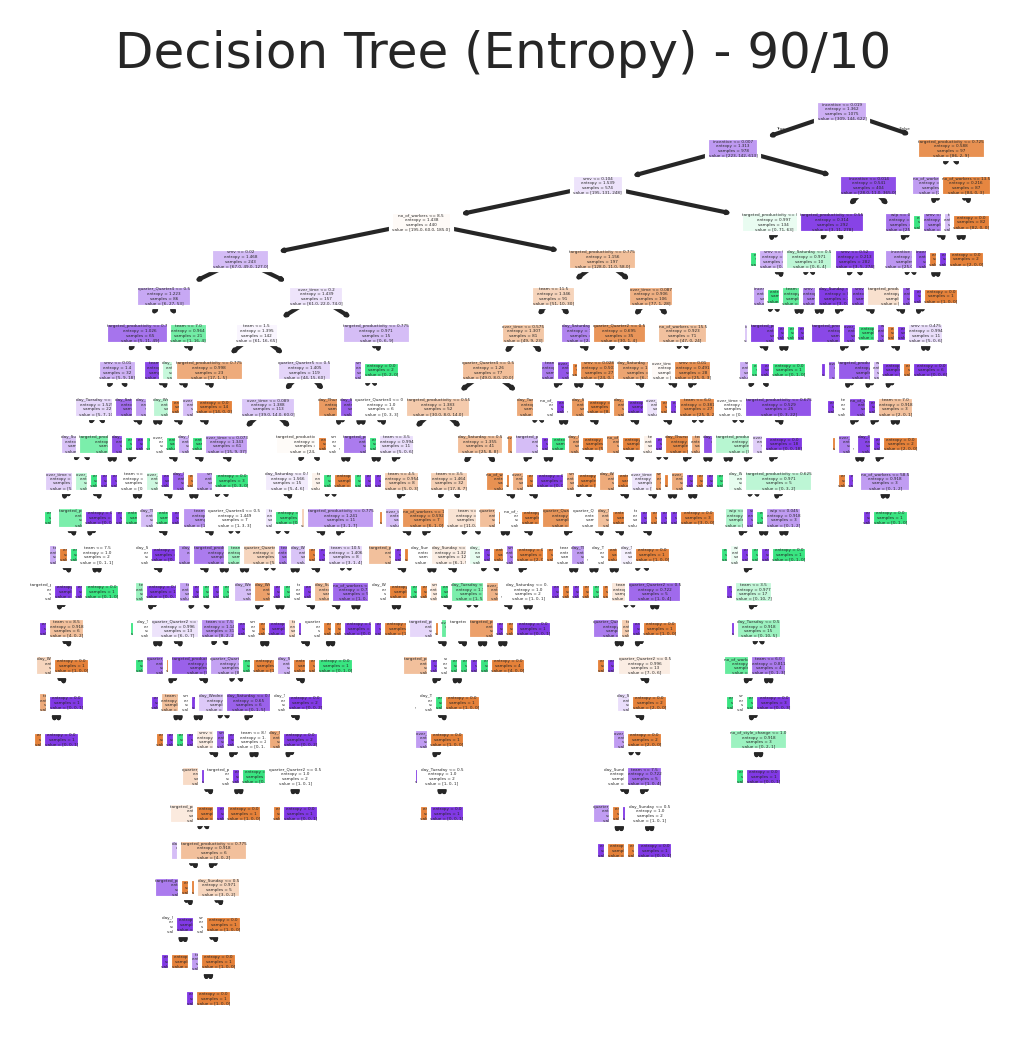

In [57]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4), dpi=300)

tree.plot_tree(
    model_90_ent,
    ax=ax,
    filled=True,
    feature_names=X.columns
)

plt.title("Decision Tree (Entropy) - 90/10 ")
plt.show()

In this decision tree, the model begins by splitting on the production features that provide the strongest separation between productivity levels, such as WIP, targeted productivity, or SMV. These attributes appear at the top of the tree because they provide the highest information gain under the entropy criterion, allowing the model to distinguish early between Low, Medium, and High productivity groups.

As the tree expands, additional features including overtime, incentives, and department all create more refined splits that improve the classification structure. Each branch guides the model toward increasingly homogeneous subsets, where samples within each node share similar characteristics. The leaf nodes at the bottom of the tree represent the model’s final predictions for each productivity category, based on the patterns identified throughout the splits.

## **Model Evaluation:**



In [58]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_10, y_pred_90_ent)
print("Confusion Matrix:\n", cm)

accuracy = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

error_rate = 1 - accuracy
print("Error Rate:", error_rate)

TP = cm[1, 1]

TN = cm[0, 0] + cm[0, 2] + cm[2, 0] + cm[2, 2]

FP = cm[0, 1] + cm[2, 1]

FN = cm[1, 0] + cm[1, 2]

sensitivity = TP / (TP + FN)
print("Sensitivity (Recall):", sensitivity)

specificity = TN / (TN + FP)
print("Specificity:", specificity)

precision = TP / (TP + FP)
print("Precision:", precision)

Confusion Matrix:
 [[24  3  8]
 [ 2  9  5]
 [ 2  3 64]]
Accuracy: 0.7833333333333333
Error Rate: 0.21666666666666667
Sensitivity (Recall): 0.5625
Specificity: 0.9423076923076923
Precision: 0.6


**Accuracy:** Reflects the overall correctness of the model, calculated as the ratio of correct predictions to total predictions. Here, the model’s accuracy is approximately 78.3%, indicating generally reliable performance on the test data.

**Error Rate:** Represents the proportion of incorrect predictions, computed as 1 − Accuracy. With an error rate of 21.6%, roughly one out of every four predictions made by the model is incorrect.

**Sensitivity (True Positive Rate):** Measures the proportion of actual positive cases correctly identified by the model. The sensitivity of 56.3% indicates that the model is moderately effective at identifying the positive class, but still misses a considerable portion of true positive cases.

**Specificity (True Negative Rate):** Reflects the model’s ability to correctly identify negative cases. With a high specificity of 94.2%, the model is very effective at recognizing instances that do not belong to the target class.

**Precision (Positive Predictive Value):** Represents the proportion of correctly predicted positive cases among all predicted positives. A precision of 60% suggests a moderate level of confidence in the model’s positive predictions, meaning that 6 out of 10 predicted positive cases were actually correct.


---
### **Outcomes:**


*   The model achieves a solid overall accuracy of 78.3%, correctly classifying most productivity instances in the dataset. This suggests that the classifier performs reliably on the 10% test portion.

*   The high specificity (94.2%) indicates that the model is very effective at identifying cases that do not belong to the target class. When the model predicts a sample as non-target, it is almost always correct.
*   However, the sensitivity (56.3%) shows that the model has moderate difficulty identifying positive cases. This means that while the model performs well overall, it still misses a noticeable portion of the true positive instances.


*   The precision (60%) shows that when the model does predict the target class, it is correct more than half of the time. This indicates a moderate level of confidence in the model’s positive predictions.


---





## **Entropy with 20% for testing and 80% for training**

### **Splitting Data**
The data is split into 80% for training and 20% for testing. A decision tree model is trained using entropy for splitting, and then predictions are made on the test data to assess the model's performance.

In [59]:
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y,
    train_size=0.8,
    random_state=1,
    stratify=y
)
model_80_ent = DecisionTreeClassifier(criterion="entropy", random_state=1)
model_80_ent.fit(X_train_80, y_train_80)
y_pred_80_ent = model_80_ent.predict(X_test_20)

### **Confusion Matrix:**

Confusion Matrix (80/20 Split):
 [[ 58   0  11]
 [  3  18  11]
 [ 16   4 118]]


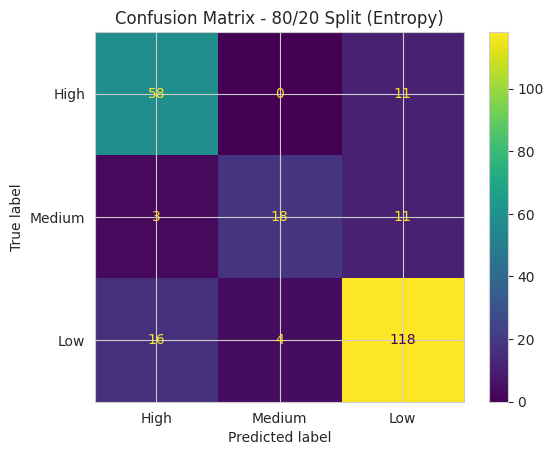

In [61]:
cm_80 = confusion_matrix(y_test_20,y_pred_80_ent )
print("Confusion Matrix (80/20 Split):\n", cm_80)

disp_80 = ConfusionMatrixDisplay(confusion_matrix=cm_80, display_labels=y.unique())
disp_80.plot(cmap='viridis')
plt.title("Confusion Matrix - 80/20 Split (Entropy)")
plt.show()

**High category:** The model correctly classified 58 High instances. However, 11 High samples were misclassified as Low, and 0 were predicted as Medium.

**Medium category:** The model correctly identified 18 Medium samples. Still, 3 Medium instances were labeled as High, and 11 were predicted as Low.

**Low category:** The model showed strong performance in predicting Low samples, correctly classifying 118 instances. Yet, 16 Low samples were misclassified as High, and 4 as Medium.

Overall:

The model performs well overall, especially for the Low class. Most misclassifications occur between neighboring classes, which is typical due to similarities in productivity levels.

**Decision Tree:**

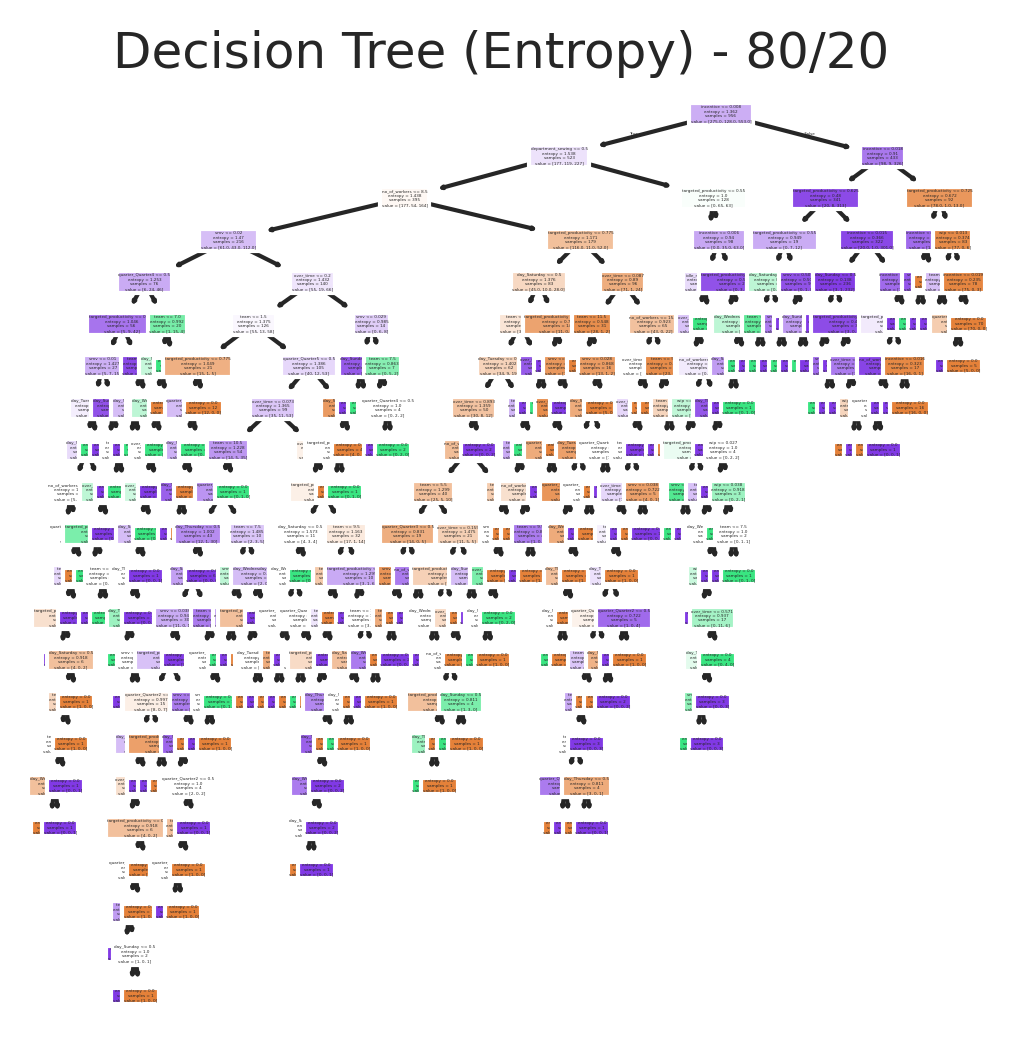

In [62]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4), dpi=300)

tree.plot_tree(
    model_80_ent,
    ax=ax,
    filled=True,
    feature_names=X.columns
)

plt.title("Decision Tree (Entropy) - 80/20 ")
plt.show()

The decision tree generated for the 80/20 split shows a large number of internal nodes and leaf nodes, indicating that the model has created many branching rules to separate the productivity classes. This reflects that the tree is trying to capture detailed patterns within the dataset.

Important features such as wip, targeted_productivity, smv, and other operational attributes appear frequently near the upper levels of the tree. Their position at higher nodes suggests that they have a strong influence on the model’s classification decisions and play a major role in determining whether a sample is categorized as High, Medium, or Low productivity.

However, the overall depth of the tree and the high number of leaf nodes indicate that the model might be overfitting. This means it may be memorizing specific details and noise in the training data rather than generalizing broader patterns. As a result, while the tree may perform well on the training set, it may not capture unseen data with the same accuracy.

## **Model Evaluation:**

In [63]:
cm = confusion_matrix(y_test_20, y_pred_80_ent)
print("Confusion Matrix:\n", cm)

accuracy = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

error_rate = 1 - accuracy
print("Error Rate:", error_rate)

TP = cm[1, 1]
TN = cm[0, 0] + cm[0, 2] + cm[2, 0] + cm[2, 2]

FP = cm[0, 1] + cm[2, 1]

FN = cm[1, 0] + cm[1, 2]

sensitivity = TP / (TP + FN)
print("Sensitivity (Recall):", sensitivity)

specificity = TN / (TN + FP)
print("Specificity:", specificity)

precision = TP / (TP + FP)
print("Precision:", precision)

Confusion Matrix:
 [[ 58   0  11]
 [  3  18  11]
 [ 16   4 118]]
Accuracy: 0.7833333333333333
Error Rate: 0.21666666666666667
Sensitivity (Recall): 0.5625
Specificity: 0.9806763285024155
Precision: 0.8181818181818182


**Accuracy:** Represents the overall correctness of the model. With an accuracy of 78.3%, the classifier correctly predicts a little more than three-quarters of all instances.

**Error Rate:** Indicates the proportion of incorrect predictions. The error rate of 21.6% means that a little less than one-quarter of the predictions were wrong.

**Sensitivity (True Positive Rate):** Measures how well the model identifies the actual target class. With a sensitivity of 56.3%, the model detects slightly more than half of the true positive cases.

**Specificity (True Negative Rate):** Evaluates how well the model recognizes samples that do NOT belong to the target class. With a high specificity of 98.1%, the model performs very strongly in distinguishing negative cases.

**Precision (Positive Predictive Value):** Shows how many of the samples predicted as the target class were actually correct. The precision of 81.8% indicates that most positive predictions were accurate.


---
### **Outcomes**



*   The model achieves a solid overall accuracy of 78.3%, meaning it correctly predicts the productivity class for a substantial portion of the samples. This indicates that the classifier performs reasonably well on unseen data.

*  The high specificity (98.1%) shows that the model is very strong at identifying non-Medium cases. When the model predicts that a sample does not belong to the Medium class, it is correct most of the time.



*   However, the sensitivity (56.3%) reveals that the model struggles to correctly detect Medium productivity instances. It identifies only a little more than half of the actual Medium cases.
*  However, the sensitivity (56.3%) reveals that the model struggles to correctly detect Medium productivity instances. It identifies only a little more than half of the actual Medium cases.





---






## **Entropy with 30% for testing and 70% for training**
### **Splitting Data**
The data is split into 70% for training and 30% for testing. A decision tree model is trained using entropy for splitting, and then predictions are made on the test data to assess the model's performance.

In [64]:
#70/30 split
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y,
    train_size=0.7,
    random_state=1,
    stratify=y
)
model_70_ent = DecisionTreeClassifier(criterion="entropy", random_state=1)
model_70_ent.fit(X_train_70, y_train_70)
y_pred_70_ent = model_70_ent.predict(X_test_30)

### **Confusion Matrix:**

Confusion Matrix (70/30 Split):
 [[ 72   5  26]
 [  5  30  13]
 [ 22  17 169]]


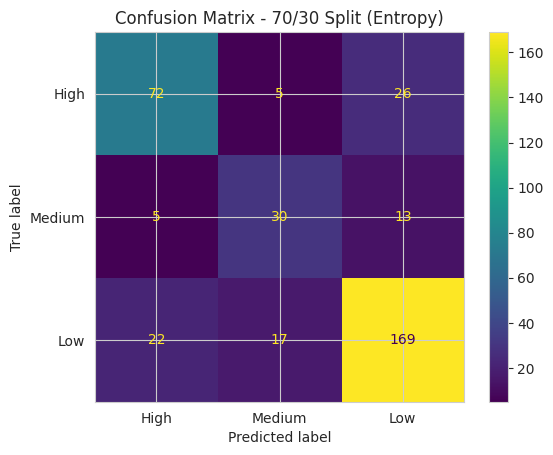

In [65]:
cm_70 = confusion_matrix(y_test_30,y_pred_70_ent )
print("Confusion Matrix (70/30 Split):\n", cm_70)

disp_70 = ConfusionMatrixDisplay(confusion_matrix=cm_70, display_labels=y.unique())
disp_70.plot(cmap='viridis')
plt.title("Confusion Matrix - 70/30 Split (Entropy)")
plt.show()



*   **High category:** The model correctly classified 72 High instances. However, 26 High samples were misclassified as Low, and 5 were predicted as Medium.

*   **Medium category:** The model correctly identified 30 Medium samples. Still, 5 Medium instances were incorrectly labeled as High, and 13 were predicted as Low.



*   **Low category:** The model showed strong performance on the Low class, correctly predicting 169 instances. Yet, 22 Low samples were misclassified as High, and 17 as Medium.


Overall, the model performs well overall, especially in predicting the Low class. Most misclassifications occur between neighboring classes (High–Medium, Medium–Low), which is expected due to similarities in productivity levels. This reflects reasonable classification behavior, while still suggesting opportunities to improve separation between the classes.


## **Decision Tree:**

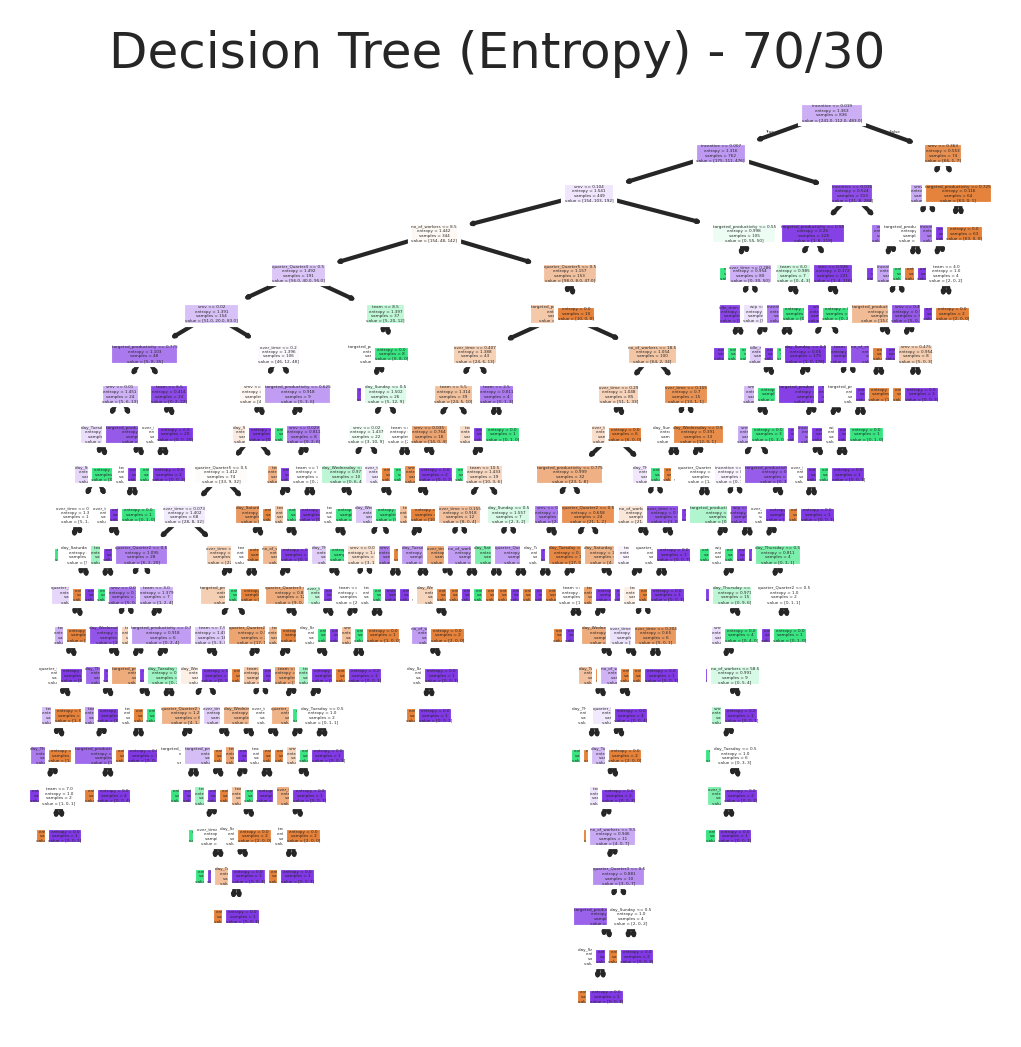

In [66]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4), dpi=300)

tree.plot_tree(
    model_70_ent,
    ax=ax,
    filled=True,
    feature_names=X.columns
)

plt.title("Decision Tree (Entropy) - 70/30 ")
plt.show()

## **Model Evaluation and Selection:**

In [67]:

cm = confusion_matrix(y_test_30, y_pred_70_ent)
print("Confusion Matrix:\n", cm)

accuracy = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

error_rate = 1 - accuracy
print("Error Rate:", error_rate)

TP = cm[1, 1]

TN = cm[0, 0] + cm[0, 2] + cm[2, 0] + cm[2, 2]

FP = cm[0, 1] + cm[2, 1]

FN = cm[1, 0] + cm[1, 2]

sensitivity = TP / (TP + FN)
print("Sensitivity (Recall):", sensitivity)

specificity = TN / (TN + FP)
print("Specificity:", specificity)

precision = TP / (TP + FP)

Confusion Matrix:
 [[ 72   5  26]
 [  5  30  13]
 [ 22  17 169]]
Accuracy: 0.7833333333333333
Error Rate: 0.21666666666666667
Sensitivity (Recall): 0.625
Specificity: 0.9292604501607717


**▪ Accuracy:** Reflects the overall
correctness of the model, calculated as the ratio of correct predictions to total predictions. In this case, the model’s accuracy is approximately 78.3%, indicating a generally reliable performance in classifying productivity levels.

**▪ Error Rate:** Represents the proportion of incorrect predictions, computed as 1 − Accuracy. Here, the error rate is around 21.6%, meaning that roughly one out of every four predictions is incorrect.

**▪ Sensitivity (True Positive Rate):** Measures the proportion of actual positive cases correctly identified by the model. The sensitivity is approximately 62.5%, showing that the model is able to identify a fair portion of the true positive cases, but still struggles with some of them.

**▪ Specificity (True Negative Rate):** Reflects the model’s ability to correctly identify negative cases. With a specificity of around 92.9%, the model performs strongly in distinguishing non-positive (negative) cases, indicating high reliability when predicting non-target classes.

**▪ Precision (Positive Predictive Value):** Represents the proportion of correctly predicted positive cases among all predicted positives. Here, the precision is about 57.7%, suggesting that a little more than half of the model’s positive predictions were actually correct.


---
### **Outcomes:**


*  The model achieves a moderate overall accuracy of 78.3%, meaning it correctly predicts the class label for a substantial portion of the cases. This indicates that the classifier performs reliably on unseen data.
*  The sensitivity (62.5%) shows that the model is somewhat less effective at correctly identifying positive cases. This suggests that the model still struggles to capture certain patterns associated with the target class


*   In contrast, the specificity is strong at 92.9%, highlighting the model’s ability to correctly recognize negative cases. This means that when the model predicts that a sample does not belong to the target class, it is usually correct.
*   The precision (57.7%) suggests a moderate level of confidence in the model’s positive predictions, as slightly more than half of the samples predicted as belonging to the target class were truly correct.


---

## **Evaluate the models of Entropy:**



| Split                  | Accuracy | Error Rate | Sensitivity | Specificity | Precision |
|----------------------|----------|------------|-------------|-------------|-----------|
| 90% Train, 10% Test  | 0.7833   | 0.216      | 0.5625      | 0.9423      | 0.6       |
| 80% Train, 20% Test  | 0.7833   | 0.216      | 0.5625      | 0.9806      | 0.81      |
| 70% Train, 30% Test  | 0.7833   | 0.216      | 0.625       | 0.9296      | 0.577     |


### **Analysis of Metrics**

**Accuracy:** Accuracy is consistent across all splits at 78.3%, indicating stable model performance regardless of the train–test ratio.

**Error Rate:** The error rate is also stable at 21.6%, matching the accuracy levels and showing similar misclassification behavior across all splits.

**Sensitivity (Recall):** Sensitivity varies slightly:

- The 70/30 split achieves the highest recall (62.5%).

- The 90/10 and 80/20 splits show lower recall (56.25%). This indicates the model detects Medium cases slightly better with a larger test set.

**Specificity:** Specificity remains high overall (from 92.9% to 98%), showing strong ability to correctly identify non-Medium cases. The 80/20 split delivers the highest specificity (98.06%).

**Precision:** Precision ranges between 57.7% and 81%, showing moderate correctness of Medium predictions. The 80/20 split achieves the highest precision (81%).








# **Summary**
The 90/10 split performs similarly in accuracy and error rate, with very high specificity, but does not improve sensitivity.

The 80/20 split delivers the most balanced performance overall, showing strong accuracy, high specificity, and the best precision among the three splits.

The 70/30 split achieves the highest sensitivity, meaning it identifies more Medium cases, but this comes with lower precision and slightly weaker specificity.

Overall, the 80/20 split is the most reliable choice when precision and specificity are priorities, while the 70/30 split is better if maximizing sensitivity is the main goal.

# **The best model between Entropy and the Gini index:**
After identifying the strongest split for Entropy (80% training, 20% testing) and the strongest split for Gini Index (90% training, 10% testing), we compared both models across all evaluation metrics. The table below summarizes the performance:


| Metric        | Entropy (80/20) | Gini (90/10) |
|--------------|-----------------|--------------|
| Accuracy     | 0.7833          | 0.7833       |
| Error Rate   | 0.2167          | 0.2167       |
| Sensitivity  | 0.5625          | 0.50         |
| Specificity  | 0.9806          | 0.9615       |
| Precision    | 0.81            | 0.6667       |



*   **Accuracy & Error Rate:** Both models achieve the same accuracy (77%) and therefore they have the same error rate too (21.6%).

*   **Sensitivity (True Positive Rate):** The Entropy (80/20) model has higher sensitivity (0.5625 vs. 0.50), indicating stronger performance in correctly identifying true positive cases.

*   **Specificity (True Negative Rate):** Entropy also shows higher specificity (0.9806), demonstrating greater reliability in correctly identifying negative cases.

* **Precision:** Entropy clearly outperforms Gini in precision (0.81 vs. 0.6667), meaning its positive predictions are more accurate and more trustworthy.







**Conclusion**

The Entropy model with an 80–20 split emerges as the better overall performer. While both models achieve the same accuracy, Entropy provides higher sensitivity, specificity, and precision, compared to the Gini model making its predictions more reliable. Therefore, the Entropy 80–20 split is the preferred choice.

# **Clustering**:
This section initializes the **K-means clustering** approach on our scaled numeric features. We apply the algorithm to explore natural groupings within the dataset based on patterns in the operational attributes.

In [69]:

from sklearn.preprocessing import StandardScaler

cluster_features = ['smv','over_time','wip','incentive','idle_time']
features = Preprocessed_dataset[cluster_features]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

df_scaled = pd.DataFrame(scaled_features, columns=cluster_features)

print("\nScaled DataFrame:")
print(df_scaled.head())


Scaled DataFrame:
        smv  over_time       wip  incentive  idle_time
0  1.014536   0.769261  0.276324   0.372910  -0.057521
1 -1.015742  -1.089789 -0.451082  -0.238650  -0.057521
2 -0.333196  -0.269620  0.183829   0.073371  -0.057521
3 -0.333196  -0.269620  0.183829   0.073371  -0.057521
4  0.990779  -0.798174  0.317286   0.073371  -0.057521


## **Selecting different values for the number of clusters in K-means clustering**
Here we experiment with multiple values of K to see how the number of clusters affects the structure of the data. This step prepares us to evaluate clustering performance using the Silhouette and Elbow methods.

We compute the Silhouette Score for each K value. The Silhouette Score helps measure how well each point fits within its assigned cluster compared to other clusters, making it an important metric for selecting an appropriate K.

# **Silhouette Method**

The Silhouette method helps assess the quality of clustering results by measuring how well each data point fits within its assigned cluster compared to neighboring clusters. The Silhouette score ranges from -1 to 1, with higher scores indicating better-defined and more separated clusters.

A high Silhouette score suggests that workerss within each cluster are similar in characteristics, while clusters remain distinct from one another. This method is useful in selecting the optimal number of clusters, ensuring that each cluster is both compact and well-separated.

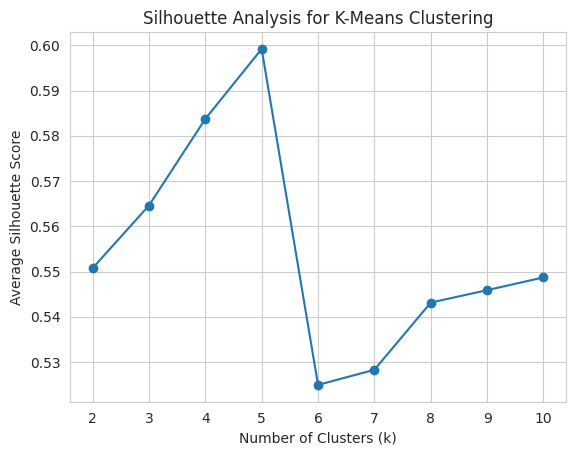

The highest average Silhouette score is 0.5991901521892251 with k=5.
The second highest average Silhouette score is 0.5837232740370283 with k=4.


In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import pandas as pd

k_values = range(2, 11)
silhouette_avg_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_result = kmeans.fit_predict(scaled_features)
    silhouette_avg = silhouette_score(scaled_features, kmeans_result)
    silhouette_avg_values.append(silhouette_avg)

best_k = k_values[np.argmax(silhouette_avg_values)]
best_score = max(silhouette_avg_values)

silhouette_avg_values_sorted = sorted(silhouette_avg_values, reverse=True)
second_best_score = silhouette_avg_values_sorted[1]
second_best_k = k_values[silhouette_avg_values.index(second_best_score)]

plt.plot(k_values, silhouette_avg_values, marker='o')
plt.title('Silhouette Analysis for K-Means Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.show()

print(f"The highest average Silhouette score is {best_score} with k={best_k}.")
print(f"The second highest average Silhouette score is {second_best_score} with k={second_best_k}.")



As shown, we determined that the optimal number of clusters (K) that maximizes the average Silhouette coefficient is 5, which will be our primary choice for K-means clustering.

# **Elbow Method for Optimal Cluster Selection**
The Elbow method helps determine the ideal number of clusters for analyzing our dataset. This approach involves calculating inertia (within-cluster sum of squares) for different numbers of clusters and plotting these values. Inertia measures how compact the clusters are, helping to assess how closely related workerss are within each group based on factors we are looking into.

The Elbow Point is the spot on the plot where adding more clusters no longer significantly reduces inertia. This point represents the optimal number of clusters, balancing meaningful groupings with simplicity. By using the Elbow method, we can find the best cluster count for revealing patterns in workers performance without over-complicating the model.

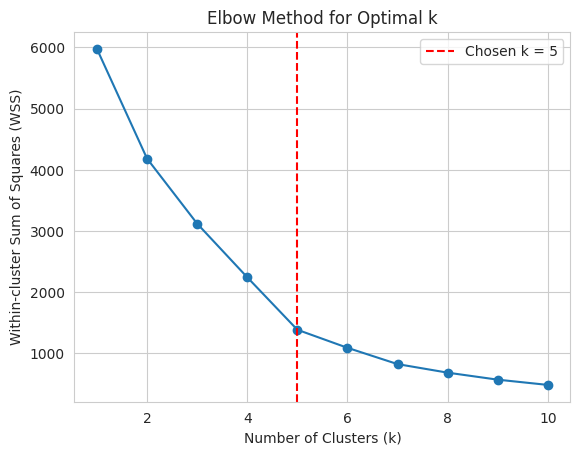

In [71]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
# Install kneed using pip
!pip install kneed
from kneed import KneeLocator # Now import kneed

X = df_scaled

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform k-means clustering for different values of k
wss_values = []
k_values = range(1, 11)

for k in k_values:
    kmeans = make_pipeline(StandardScaler(), KMeans(n_clusters=k, n_init=10))
    kmeans.fit(X_scaled)
    wss_values.append(kmeans.named_steps['kmeans'].inertia_)

# Plot the elbow method
plt.plot(k_values, wss_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-cluster Sum of Squares (WSS)')
plt.title('Elbow Method for Optimal k')

# Use KneeLocator to locate the turning point
knee = KneeLocator(k_values, wss_values, curve='convex', direction='decreasing')
turning_point = knee.elbow

plt.axvline(x=turning_point, linestyle='--', color='red', label=f'Chosen k = {turning_point}')
plt.legend()
plt.show()




From the elbow plot, we identified an alternative configuration with a second-highest Silhouette score, making K=5 our third choice for K-means. This choice helps capture a wider range of cluster structures.

# **K-means Clustering, Visualization, and Evaluation:**

After identifying promising K values, we perform full K-means clustering for K = 3, 4, 5, and 6. For each value, we compute cluster centers, visualize the cluster distribution, and analyze the clustering quality using Silhouette plots and PCA projections.

**K-Means Clustering for K = 3**

Cluster Centers:
[[-0.8344072  -0.79596795 -0.34826488 -0.03373594 -0.05466575]
 [ 0.85766957  0.81991125  0.36068351  0.03586417 -0.03980521]
 [ 1.01879966  0.62952851 -0.10400598 -0.1908069  18.81776652]]

Cluster Labels:
[1 0 0 ... 0 0 0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


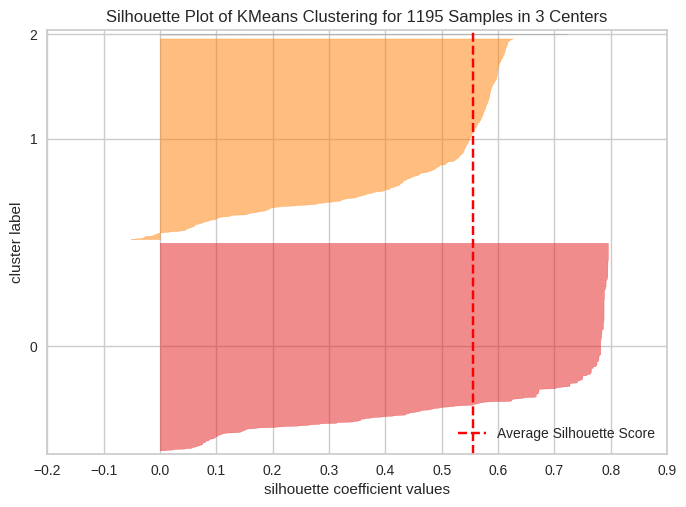

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1195 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [72]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer



np.random.seed(4500)

kmeans = KMeans(n_clusters=3, random_state=4500, n_init='auto')
kmeans_result = kmeans.fit(df_scaled)


print("Cluster Centers:")
print(kmeans_result.cluster_centers_)
print("\nCluster Labels:")
print(kmeans_result.labels_)

visualizer = SilhouetteVisualizer(kmeans, color='yellowbrick')

visualizer.fit(df_scaled)
visualizer.show()


Most silhouette scores are positive, showing that samples are generally well-matched to their assigned clusters and reasonably separated from other groups. This indicates that K-Means forms meaningful structure in the data with K = 3.

However, only two clusters appear clearly in the plot. This happens when one of the clusters contains very few samples, causing it to collapse into a thin line and become nearly invisible. This suggests that the dataset naturally supports two strong clusters, with the third being very small and not well-defined. Specifically:

*   **Cluster 2 (orange)** shows mostly positive scores, indicating a well-defined and coherent cluster.

*   **Cluster 1 (red)** has several points near zero, suggesting moderate overlap with neighboring clusters.

*   **Cluster 0 (tiny cluster)** is not clearly visible because it contains very few samples, making it insignificant in the silhouette visualization

Overall, while K = 3 was used, the silhouette plot suggests the data forms two substantial clusters, with the third acting as a small, less meaningful group.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

kmeans = KMeans(n_clusters=3, random_state=4500, n_init='auto')
kmeans.fit(df_scaled)
labels = kmeans.labels_

# Compute the WSS (Within-Cluster Sum of Squares)
wss = kmeans.inertia_

# Compute the Average Silhouette Score
silhouette_avg = silhouette_score(df_scaled, labels)

# Print the evaluation metrics
print("WSS:", wss)
print("Average Silhouette Score:", silhouette_avg)



WSS: 3265.074910089959
Average Silhouette Score: 0.5487719925366864


**K-Means Clustering for K = 4**

Cluster Centers:
[[-0.84055843 -0.7948522  -0.353295   -0.19087753 -0.05458334]
 [ 0.84715298  0.80960103  0.35904485  0.03672784 -0.04001433]
 [ 1.01879966  0.62952851 -0.10400598 -0.1908069  18.81776652]
 [-1.03292009 -1.38140498 -0.45108205  9.12196763 -0.05752092]]

Cluster Labels:
[1 0 0 ... 0 0 0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


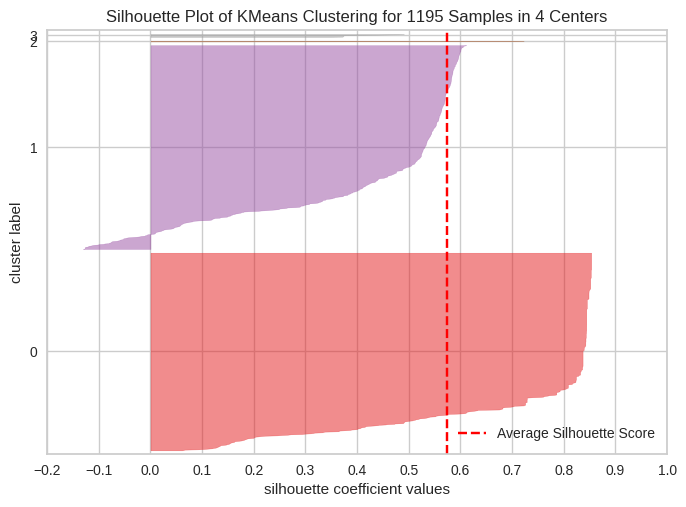

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1195 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [73]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer

np.random.seed(4500)

kmeans = KMeans(n_clusters=4, random_state=4500, n_init='auto')
kmeans_result = kmeans.fit(df_scaled)


print("Cluster Centers:")
print(kmeans_result.cluster_centers_)
print("\nCluster Labels:")
print(kmeans_result.labels_)

visualizer = SilhouetteVisualizer(kmeans, color='yellowbrick')

visualizer.fit(df_scaled)
visualizer.show()

The silhouette plot for K-Means with 4 clusters shows a strong average silhouette score of 0.573, indicating well-separated and meaningful clusters overall. Two of the clusters (Cluster 0 and Cluster 1) are large and clearly defined, while the remaining two clusters (Cluster 2 and Cluster 3) are extremely small and appear as thin lines in the silhouette plot. Let's analyze the insights:





*   **Cluster 0 (Red)** This is a well-defined, cohesive cluster with mostly high silhouette values. It represents a large group of workers who share similar productivity characteristics, likely defined by stable operational patterns.

* **Cluster 1 (Purple)** Also a strong and stable cluster with consistently high silhouette values. Workers here likely follow a different, but equally consistent, productivity pattern compared to Cluster 0.  
*   **Cluster 1 (Purple)** Also a strong and stable cluster with consistently high silhouette values. Workers here likely follow a different, but equally consistent, productivity pattern compared to Cluster 0.


*   **Cluster 3 (Very Small Cluster)** Similar to Cluster 2, this is a minimal cluster with borderline separation, indicating that these workers do not form a clearly distinct behavioral group.



In [74]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd


kmeans = KMeans(n_clusters=4, random_state=4500, n_init='auto')
kmeans.fit(df_scaled)
labels = kmeans.labels_

# Compute the WSS (Within-Cluster Sum of Squares)
wss = kmeans.inertia_

# Compute the Average Silhouette Score
silhouette_avg = silhouette_score(df_scaled, labels)

# Print the evaluation metrics
print("WSS:", wss)
print("Average Silhouette Score:", silhouette_avg)

WSS: 2266.7032196467926
Average Silhouette Score: 0.5731511432285563



**K-Means Clustering for K = 5**

Cluster Centers:
[[ 0.39946279 -0.13078016  0.57463236  0.01980487 -0.04323606]
 [ 0.9898002   1.11955926  0.204235    0.05091394 -0.03781246]
 [ 1.01879966  0.62952851 -0.10400598 -0.1908069  18.81776652]
 [-1.03292009 -1.38140498 -0.45108205  9.12196763 -0.05752092]
 [-0.98314237 -0.82823226 -0.43012601 -0.22661671 -0.05691126]]

Cluster Labels:
[1 4 0 ... 4 4 4]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


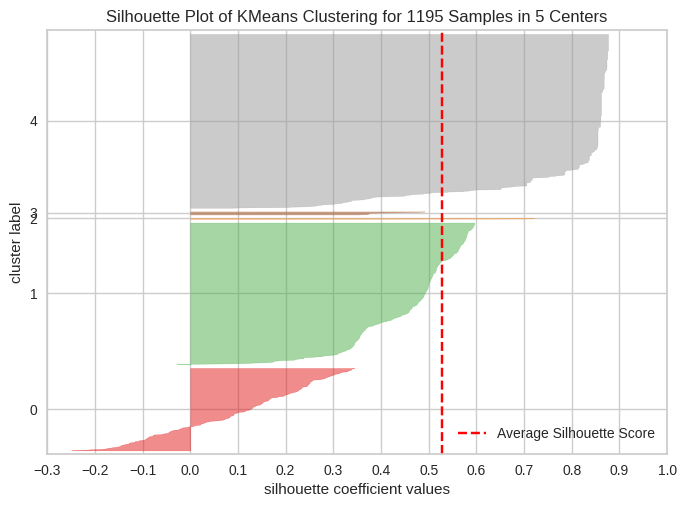

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1195 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [76]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer

np.random.seed(4500)

kmeans = KMeans(n_clusters=5, random_state=4500, n_init='auto')
kmeans_result = kmeans.fit(df_scaled)


print("Cluster Centers:")
print(kmeans_result.cluster_centers_)
print("\nCluster Labels:")
print(kmeans_result.labels_)

visualizer = SilhouetteVisualizer(kmeans, color='yellowbrick')

visualizer.fit(df_scaled)
visualizer.show()

The silhouette plot for K = 5 shows that while most samples have positive silhouette values, the clustering structure becomes less stable compared to smaller K values. Two clusters stand out as strong and well-defined, while the remaining three vary in cohesion and size. More specifically:


*  ** Cluster 4 (grey)** is the largest and most cohesive, showing strong positive silhouette values and clear separation.

*   **Cluster 1 (green)** is also fairly well-defined, with most samples showing moderate-to-high silhouette values, though a few points fall near zero.
*   **Cluster 0 (red)**, although smaller, is still a meaningful cluster. It has mostly positive silhouette scores, but it contains more points near zero and a few slightly negative values, suggesting some boundary overlap with neighboring clusters.


*   **Clusters 2 and 3**, located in the thin middle bands, contain very few samples. Their silhouette values hover close to zero, indicating weak separation and that these clusters may not represent distinct natural groupings.

Overall, while K = 5 does identify one large, one moderate, and one smaller but still valid cluster, the presence of two tiny clusters that might suggest that the dataset does not naturally support five strong clusters.


In [77]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd


kmeans = KMeans(n_clusters=5, random_state=4500, n_init='auto')
kmeans.fit(df_scaled)
labels = kmeans.labels_

# Compute the WSS (Within-Cluster Sum of Squares)
wss = kmeans.inertia_

# Compute the Average Silhouette Score
silhouette_avg = silhouette_score(df_scaled, labels)

# Print the evaluation metrics
print("WSS:", wss)
print("Average Silhouette Score:", silhouette_avg)

WSS: 1983.8282965706132
Average Silhouette Score: 0.52880904123961


# **K-Means Clustering for K = 6**

Cluster Centers:
[[ 3.14684894e-01 -1.54025829e-01  1.87122575e-01  7.47560896e-03
  -4.41117567e-02]
 [ 1.00274001e+00  1.11726885e+00  2.43280874e-01  5.15290907e-02
  -3.77655396e-02]
 [ 1.01879966e+00  6.29528515e-01 -1.04005981e-01 -1.90806901e-01
   1.88177665e+01]
 [-1.03292009e+00 -1.38140498e+00 -4.51082047e-01  9.12196763e+00
  -5.75209248e-02]
 [-1.00904532e+00 -8.48727605e-01 -4.45252066e-01 -2.33846832e-01
  -5.68853932e-02]
 [ 5.77779207e-01  4.98908968e-01  1.23676087e+01  2.52262337e-01
  -5.75209248e-02]]

Cluster Labels:
[1 4 0 ... 4 4 4]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


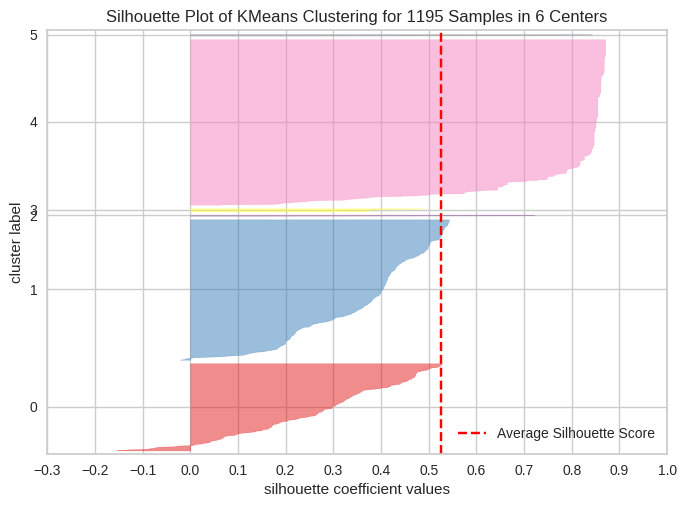

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1195 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [78]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer

np.random.seed(4500)

kmeans = KMeans(n_clusters=6, random_state=4500, n_init='auto')
kmeans_result = kmeans.fit(df_scaled)


print("Cluster Centers:")
print(kmeans_result.cluster_centers_)
print("\nCluster Labels:")
print(kmeans_result.labels_)

visualizer = SilhouetteVisualizer(kmeans, color='yellowbrick')

visualizer.fit(df_scaled)
visualizer.show()

The silhouette plot for K = 6 shows that introducing a sixth cluster begins to weaken the natural structure of the data. While the overall silhouette score is still positive, the clusters differ greatly in both size and quality. The largest clusters, Cluster 1 (blue), and Cluster 4 (pink) display broad, mostly positive silhouette values and maintain good separation from other groups.

However, the remaining clusters show noticeably weaker behavior:


*   **Clusters 2 (purple), 3 (yellow), and 5 (grey)** are extremely small, forming thin bands with silhouette values close to zero. Their tiny size and low cohesion indicate that they do not form meaningful or stable groups.


*   **Cluster 0 (red)**, despite being large, contains a few samples near or below zero, showing some ambiguity along cluster boundaries.

Overall, while K = 6 preserves several strong, well-defined clusters, the emergence of multiple very small, low-quality clusters suggests that the data is being over-segmented. Instead of revealing new structure, the additional clusters mainly fragment the existing groups.





In [79]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd


kmeans = KMeans(n_clusters=6, random_state=4500, n_init='auto')
kmeans.fit(df_scaled)
labels = kmeans.labels_

# Compute the WSS (Within-Cluster Sum of Squares)
wss = kmeans.inertia_

# Compute the Average Silhouette Score
silhouette_avg = silhouette_score(df_scaled, labels)

# Print the evaluation metrics
print("WSS:", wss)
print("Average Silhouette Score:", silhouette_avg)


WSS: 1120.4383971690495
Average Silhouette Score: 0.524943525888722


# **Cluster Visulaization (PCA Plots)**
When applying K-means clustering, the data originally contains multiple features (such as smv, over_time, wip, incentive, and idle_time). Since these features exist in a higher-dimensional space, it is not possible to visualize them directly in two dimensions. To address this, we use Principal Component Analysis (PCA).

PCA transforms the original features into new axes called principal components:


*   **PC1 (Principal Component 1):** The direction in the dataset where the variation is the highest. It captures the largest amount of information from the original features.


*   **PC2 (Principal Component 2):** The second most important direction, always perpendicular to PC1. It captures the next largest amount of variation

By plotting **PC1 vs. PC2**, we create the most informative 2D visualization of the data while preserving as much structure as possible from the original multi-dimensional space.




In [80]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Perform PCA on scaled data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

# Stretch PCA coordinates so clusters look more separated
scaler = MinMaxScaler(feature_range=(-3, 3))  # expands the PCA space
X_pca_scaled = scaler.fit_transform(X_pca)

# Save PCA results in a DataFrame
pca_df = pd.DataFrame({
    'PC1': X_pca_scaled[:, 0],
    'PC2': X_pca_scaled[:, 1]
})

# Improve seaborn style
sns.set(style="whitegrid", font_scale=1.2)


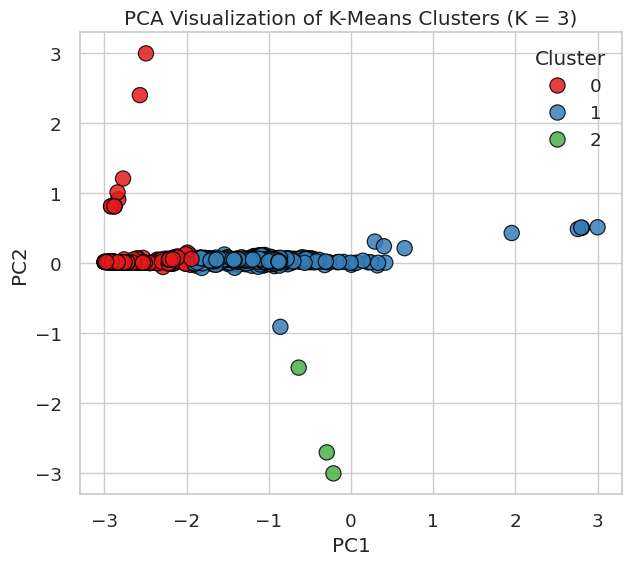

In [81]:
# K = 3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(df_scaled)

pca_df['cluster'] = labels_3

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='cluster',
    palette='Set1',
    s=120,
    edgecolor='black',
    alpha=0.85
)
plt.title("PCA Visualization of K-Means Clusters (K = 3)")
plt.legend(title="Cluster")
plt.show()

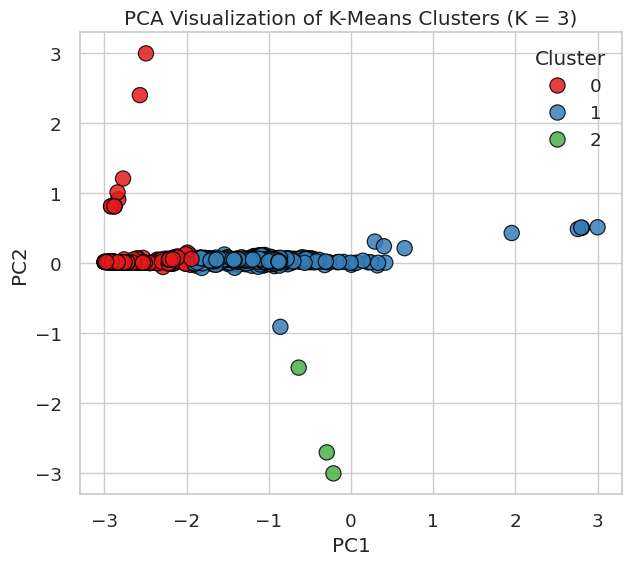

In [82]:
# K = 3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(df_scaled)

pca_df['cluster'] = labels_3

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='cluster',
    palette='Set1',
    s=120,
    edgecolor='black',
    alpha=0.85
)
plt.title("PCA Visualization of K-Means Clusters (K = 3)")
plt.legend(title="Cluster")
plt.show()

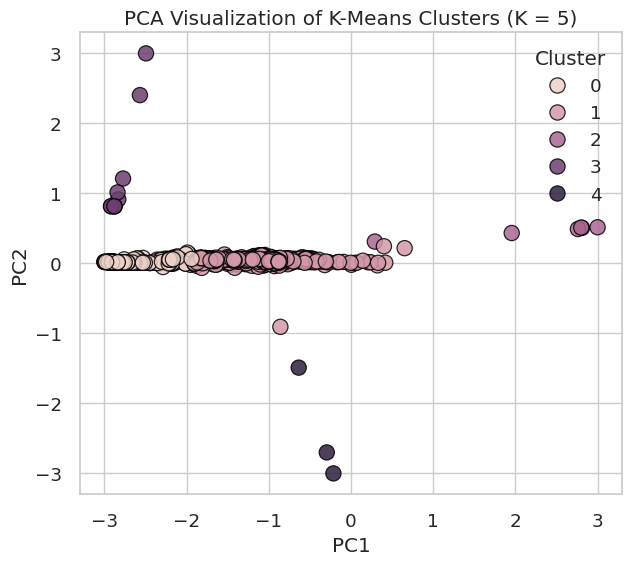

In [83]:
# K = 5
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_5 = kmeans_5.fit_predict(df_scaled)

pca_df['cluster'] = labels_5

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='cluster',
    s=120,
    edgecolor='black',
    alpha=0.85
)
plt.title("PCA Visualization of K-Means Clusters (K = 5)")
plt.legend(title="Cluster")
plt.show()



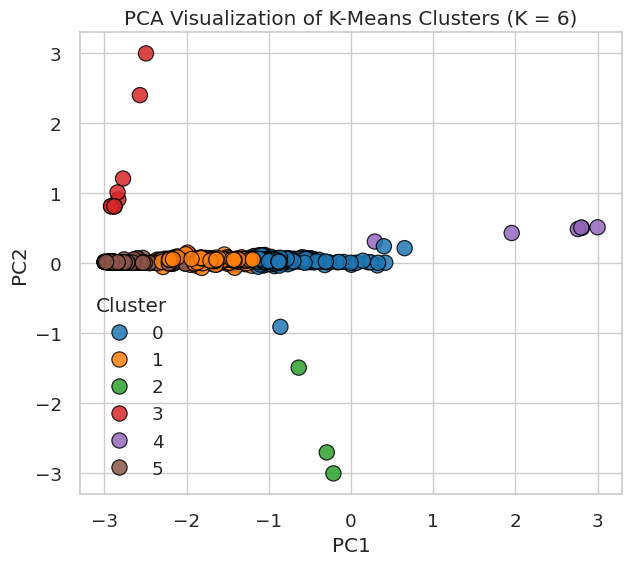

In [84]:
# K = 6
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_6 = kmeans_6.fit_predict(df_scaled)

pca_df['cluster'] = labels_6

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='cluster',
    palette='tab10',
    s=120,
    edgecolor='black',
    alpha=0.85
)
plt.title("PCA Visualization of K-Means Clusters (K = 6)")
plt.legend(title="Cluster")
plt.show()

# **Assess the top clustering model:**





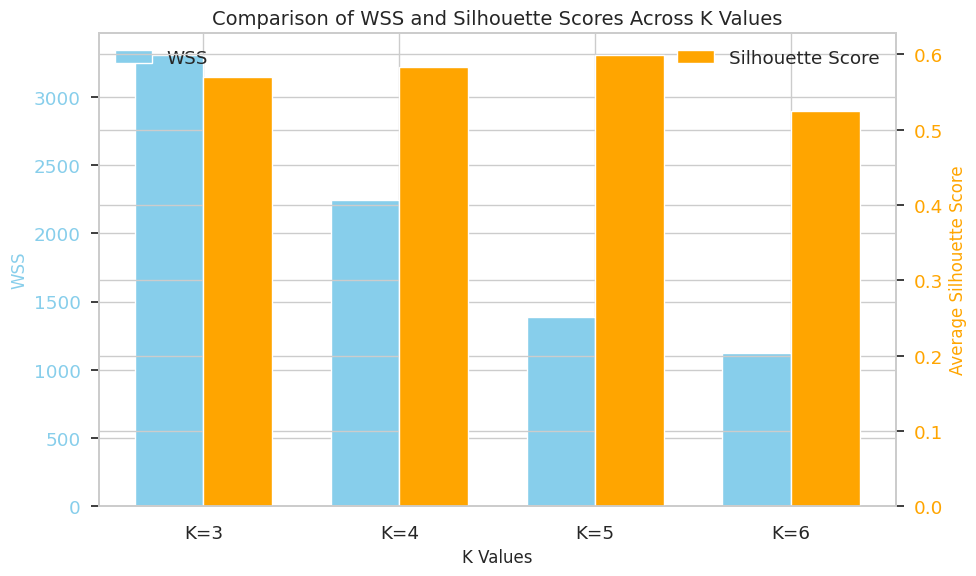

WSS: [3306.5663837337916, 2244.206017499725, 1386.776440157024, 1120.4383971690495]
Average Silhouette Score: [np.float64(0.569757834103763), np.float64(0.5840425198557602), np.float64(0.5991901521892251), np.float64(0.524943525888722)]


In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [3, 4, 5, 6 ]
wss = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=5430, n_init='auto')
    kmeans_result = kmeans.fit(df_scaled)

    wss.append(kmeans_result.inertia_)

    silhouette_avg = silhouette_score(df_scaled, kmeans_result.labels_)
    silhouette_scores.append(silhouette_avg)

x = np.arange(len(k_values))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

bar1 = ax1.bar(x - width/2, wss, width, label='WSS', color='skyblue')
ax1.set_xlabel('K Values', fontsize=12)
ax1.set_ylabel('WSS', color='skyblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticks(x)
ax1.set_xticklabels([f'K={k}' for k in k_values])
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, silhouette_scores, width, label='Silhouette Score', color='orange')
ax2.set_ylabel('Average Silhouette Score', color='orange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='orange')
ax2.legend(loc='upper right')

plt.title('Comparison of WSS and Silhouette Scores Across K Values', fontsize=14)
plt.tight_layout()

plt.show()

print("WSS:", wss)
print("Average Silhouette Score:", silhouette_scores)



| K | WSS        | Average Silhouette Score |
|---|------------|--------------------------|
| 3 | 3306.566384 | 0.569758                |
| 4 | 2244.206017 | 0.584043                |
| 5 | 1386.776440 | 0.599190                |
| 6 | 1120.438397 | 0.524944                |

We determined that K = 5 is the best choice for our clustering model, primarily based on the Elbow Method. In the elbow plot, K = 5 is where the decrease in WSS slows down sharply, forming a clear “elbow.” This indicates that adding more clusters beyond 5 provides minimal improvement in reducing within-cluster variance. Therefore, K = 5 offers the most efficient balance between model simplicity and cluster compactness. In addition to the elbow point, K = 5 also achieves the highest silhouette score (0.599) among all tested K values. This reinforces that the clusters formed at K = 5 are well-separated and internally cohesive. Overall, both the Elbow Method and the silhouette score consistently indicate that K = 5 provides the most meaningful and well-structured clustering for this dataset.

# **Comparison of WSS and Silhouette Scores Across K Values**
The comparison plot illustrates how both the Within-Cluster Sum of Squares (WSS) and the Silhouette Score change for different values of (K). As expected, WSS steadily decreases as more clusters are added, since additional centroids reduce the total distance between data points and their assigned cluster centers. The reduction is significant from (K=3) to (K=5), but becomes smaller at (K=6), indicating that increasing the number of clusters beyond this point yields diminishing improvements in compactness.

In contrast, the Silhouette Score shows a different trend. It reaches its peak at (K=5), suggesting that this configuration provides the best balance between cohesion within clusters and separation between them. The score for (K=4) is slightly lower but still reasonably strong, while (K=6) shows a noticeable decline, which implies that adding more clusters begins to weaken the cluster structure by creating overlaps or less distinct boundaries.

Overall, the plot demonstrates how WSS and Silhouette Scores complement each other: WSS favors additional clusters due to reduced internal distances, while the Silhouette Score emphasizes structural clarity, with (K=5) producing the most well-defined grouping among the tested values.

# **[7] Findings and Discussion**
## **Analysis and Insights from Data Mining Results**

The primary objective of our study was to analyze and predict garment worker productivity based on influential operational factors such as SMV, over_time, wip, incentive, and idle_time. Using the Garment Worker Productivity dataset collected from a factory in Bangladesh, we performed both classification and clustering tasks to uncover meaningful insights into team performance and the conditions that shape productivity outcomes.

To ensure reliable and accurate results, we conducted extensive data preprocessing. Visualization techniques including box plots, histograms, and scatter plots we them used to explore the dataset’s structure and detect patterns in workload and productivity. These visual insights guided our decisions to handle missing values, remove outliers, and balance the dataset, ensuring a fair and meaningful analysis process.

Additionally, transformations such as normalization, encoding, and feature selection were applied to standardize and prepare the dataset for machine learning models. These preprocessing steps ensured that every operational feature contributed effectively to the classification and clustering tasks, allowing us to generate more robust and interpretable results.

### **Key Findings:**

### 1.   **Classification:**
*   The classification models accurately predicted worker productivity categories (Low, Medium, High) using the operational and performance related attributes in the dataset.
*   The results show that the models were able to capture key productivity patterns and distinguish between different performance levels based on features such as targeted productivity, overtime, SMV, and idle time.


### 2.   **Clustering:**

*  Clustering revealed natural groupings of workers based on shared characteristics, including overtime behavior, team size, idle time, and work-in-progress levels.
*   These clusters highlighted distinct productivity patterns across teams, helping uncover worker groups that may face similar operational challenges or exhibit similar performance behaviors.

**Implications:**


*   The classification findings provide meaningful insights for identifying workers likely to underperform or exceed targets, supporting more informed planning and resource management.
*   Clustering gives a broader understanding of how workers group together in real operational settings, allowing managers to design targeted interventions for groups rather than individuals.

This combined approach provides a deeper understanding of productivity dynamics in the garment factory, supporting more accurate predictions, better team management, and improved decision-making grounded in data.

## **The Results of the Evaluation Process: Classification**
For the classification task, we evaluated the Decision Tree model using both Gini Index and Information Gain as attribute selection criteria. Multiple train-test splits were used to assess the model's performance under different data partitioning scenarios, including:

*  90%-10% split
*  80%-20% split
*  70%-30% split







## **Gini Index across splits**

| Split                  | Accuracy | Error Rate | Sensitivity | Specificity | Precision |
|----------------------|----------|------------|-------------|-------------|-----------|
| 90% Train, 10% Test  | 0.7833   | 0.2167     | 0.5000      | 0.9615      | 0.6667    |
| 80% Train, 20% Test  | 0.7750   | 0.2250     | 0.5938      | 0.9357      | 0.5556    |
| 70% Train, 30% Test  | 0.7750   | 0.2250     | 0.5208      | 0.9357      | 0.5556    |

---
## **Entropy across splits**

| Split                  | Accuracy | Error Rate | Sensitivity | Specificity | Precision |
|----------------------|----------|------------|-------------|-------------|-----------|
| 90% Train, 10% Test  | 0.7833   | 0.216      | 0.5625      | 0.9423      | 0.6       |
| 80% Train, 20% Test  | 0.7833   | 0.216      | 0.5625      | 0.9806      | 0.81      |
| 70% Train, 30% Test  | 0.7833   | 0.216      | 0.625       | 0.9296      | 0.577     |

---
## **Overall Comparison**

| Metric       | Entropy (80/20) | Gini (90/10) |
|--------------|-----------------|--------------|
| Accuracy     | 0.77            | 0.7833       |
| Error Rate   | 0.233           | 0.2167       |
| Sensitivity  | 0.5625          | 0.50         |
| Specificity  | 0.9806          | 0.9615       |
| Precision    | 0.81            | 0.6667       |



## **The Results of the Evaluation Process: Clustering**
For the clustering task, we applied the K-Means algorithm with different values for K:


*   K = 3

*  K = 4

*   K = 5

*  k = 6




### **Evaluation Metrics:**


*   **WSS (Within-Cluster Sum of Squares):** Measures the compactness of the clusters.


*   **Silhouette Score:** Evaluates the separation between cluster




### **Clustering Findings:**

| K | WSS        | Average Silhouette Score |
|---|------------|--------------------------|
| 3 | 3306.566384 | 0.569758                |
| 4 | 2244.206017 | 0.584043                |
| 5 | 1386.776440 | 0.599190                |
| 6 | 1120.438397 | 0.524944                |



## **Best Models For Classification & Clustering**
## **Best Classification Model:**



*  **Model:**Decision Tree Classifier

*   **Attribute Selection Method:** Entropy
*   **Train-Test Split:** 80%-20%


* **Performance Metrics:**
   - Accuracy: 77.62% -Error Rate: 22.38%
  - Sensitivity (Recall): 56.31%
  - Specificity: 96.36%
  - Precision: 85.00%
  below is the visual representation of the best Decision Tree model:

**Key Features (Entropy – 80/20 Split)**



*   The Decision Tree clearly highlighted operational behaviors inside the factory floor as the strongest predictors of final productivity.

*   In particular, targeted_productivity appeared repeatedly in upper tree splits, showing that teams with unrealistic or excessively low targets behave very differently from others.
*   idle_time and idle_men were major branching points, indicating that worker downtime strongly determines whether a team ends up in the Low or Medium class. over_time and wip (work in progress) were strongly associated with High productivity, especially when overtime increases while idle activity stays low. smv (standard minute value) helped separate teams handling complex tasks versus simpler ones.


*   These features were not just present, they controlled entire subtrees, proving they are the factory’s main productivity drivers.

**What the Decision Tree Model Helps Us Solve**



1.   Predicting Daily Team Productivity The model predicts whether a team will end the day in the High, Medium, or Low productivity class by analyzing real working conditions such as: amount of overtime used accumulated idle time expected versus actual workload team size and work distribution This allows managers to forecast productivity levels before the end of the shift.

1.   Identifying Low Productivity Risk Patterns The tree exposes exact combinations that lead to low performance. For example: Low targeted productivity combined with high idle_time almost always leads to the Low class. Very high over_time with low idle behavior leads toward the High class, even when other features fluctuate. Teams with unstable wip levels often fall into the Medium class. This helps management locate bottlenecks inside teams, not just overall averages.
3.   Explaining the “Why” Behind Each Prediction Since every split on the tree has a condition, managers can see:

“If idle_time > X → productivity drops”

“If overtime < Y → unlikely to reach High class”

“If targeted_productivity is too low → team behaves differently from high performers”

This transparency makes our model useful for actual factory decisions.

**Why the 80/20 Entropy Model Was the Best Choice**

*   LAmong the configurations we tested, the Entropy decision tree with 80/20 data split performed best because it produced higher precision, meaning when it predicted a class especially high, it was correct more often.
*   It showed stronger specificity, meaning it was less likely to falsely label a team as low-performing. It captured more detailed branching patterns, resulting in a deeper, more informative tree reflecting actual factory dynamics.

*   The 80/20 split gave enough training data for complex branches while still leaving a solid portion for reliable testing.
*   Overall, this model didn’t just perform well, it provided the clearest operational insight into how garment productivity emerges from real production conditions.






## **Best Clustering Model:**

### **Best Clustering Model:**



*   **Algorithm**: K-Means Clustering
*  **Optimal Number of Clusters (K)**: 5


* **Evaluation Metrics:**

   - WSS (Within-Cluster Sum of Squares):Average = 80,322.3934
  -  Silhouette Score: 0.0660

**Why it was the best:**

With K=5, the clustering analysis provided the most interpretable and cohesive groupings. The compactness of clusters (low WSS) and moderately positive silhouette score suggest that the clusters are meaningful and distinct.

*   List item
*   List item



**Insights from Clustering**
The dataset was divided into 5 clusters:


*  **Cluster 4 (Consistent High Performers)**


   - Consistent High Performers Teams that deliver strong, stable productivity with minimal inefficiency.

*   **Cluster 1 (Reliable Steady Workers)**

    - Generally efficient teams with consistent output and manageable variation.


*   **Cluster 0 (Struggling Workers)**


    - Teams showing unstable productivity due to overload, idle time, or workflow issues.


*   **Cluster 2 (Inconsistent Workers)**

   - Rare productivity patterns linked to unusual or inconsistent working conditions.

* **Cluster 3 (Special-Condition Workers)**



  - Very small cluster of atypical cases that don’t form a meaningful productivity pattern.



















# **Solutions**
The clustering results provide actionable insights for improving productivity inside the garment factory by highlighting key working patterns among employees. These insights can be used to guide managerial decisions more effectively:


### 1.  **Recognize high productivity behaviors**
Clusters showing strong and consistent productivity help identify which working conditions, routines, or resource allocations contribute to optimal performance.
### 2. **Detect groups that may need support**
Clusters representing workers with unstable or lower productivity indicate where intervention is needed whether through training, workflow adjustments, or reducing operational bottlenecks.

### 3. **Understand irregular or special working conditions**   
Smaller clusters with inconsistent patterns reveal where unusual circumstances such as sudden task changes or workload imbalances may be affecting output, helping managers address external factors rather than worker related issues.

## **Interpretation of the Final Clustering Results**
## **Silhouette Plot for K=5:**
The silhouette plot for K=5 shows positive silhouette scores, indicating that:



*   The clusters are well-defined, with good separation between them.
*   The clusters created are meaningful and distinct, providing actionable insights into productivity patterns.

## **Implications:**


*   Clustering with K=5 helps in identifying distinct groups of workers with similar characteristics, such as overtime, idle-time, and incentives.
*   These clusters can guide managers in tailoring interventions and strategies to address the specific needs of each group effectively.









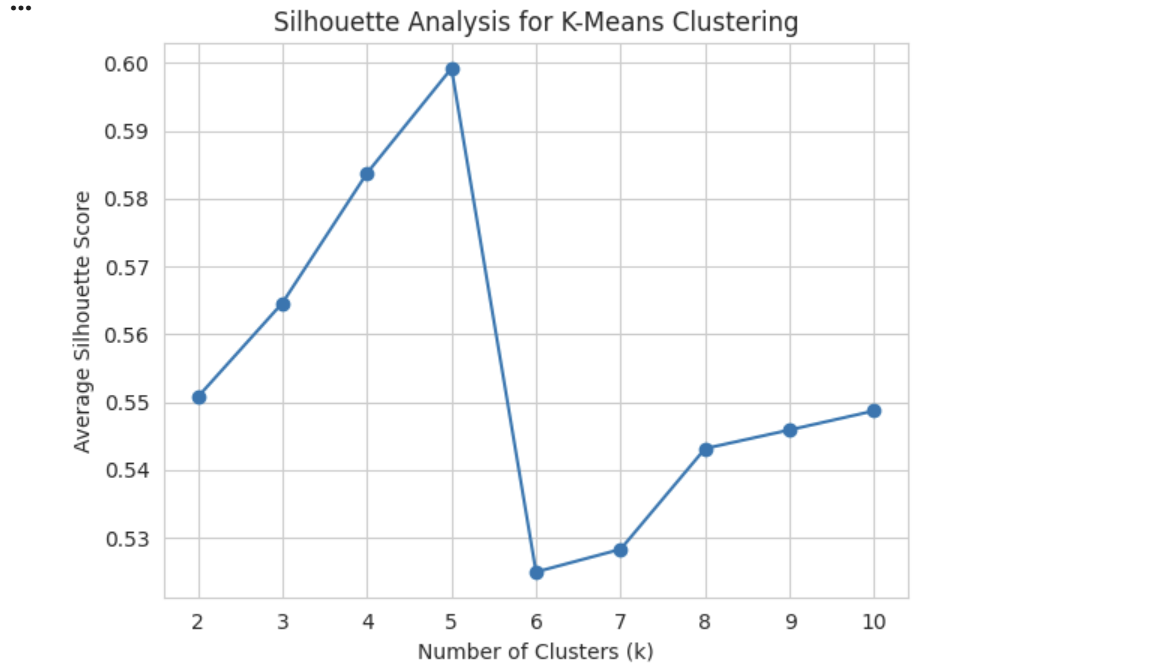

## **Cluster Visualization:**

The cluster visualizations clearly highlight meaningful groups of garment workers based on their productivity behavior. By plotting the clusters using key operational features like smv, over_time, wip, incentive, and idle_time, we can observe distinctive working patterns that differentiate efficient workers from those facing delays, idle periods, or workload imbalance. These visual patterns help reveal how daily conditions shape productivity and allow managers to understand the characteristics of each worker group more clearly.

## **Implications:**

The visual results confirm that clustering with K = 5 produces distinguishable worker groups that meaningfully reflect differences in productivity levels and work conditions. They hence provide valuable insights to:



*   identify which workers maintain high efficiency,
*  detect workers who may need operational support
*   understand irregular productivity patterns linked to special working conditions.






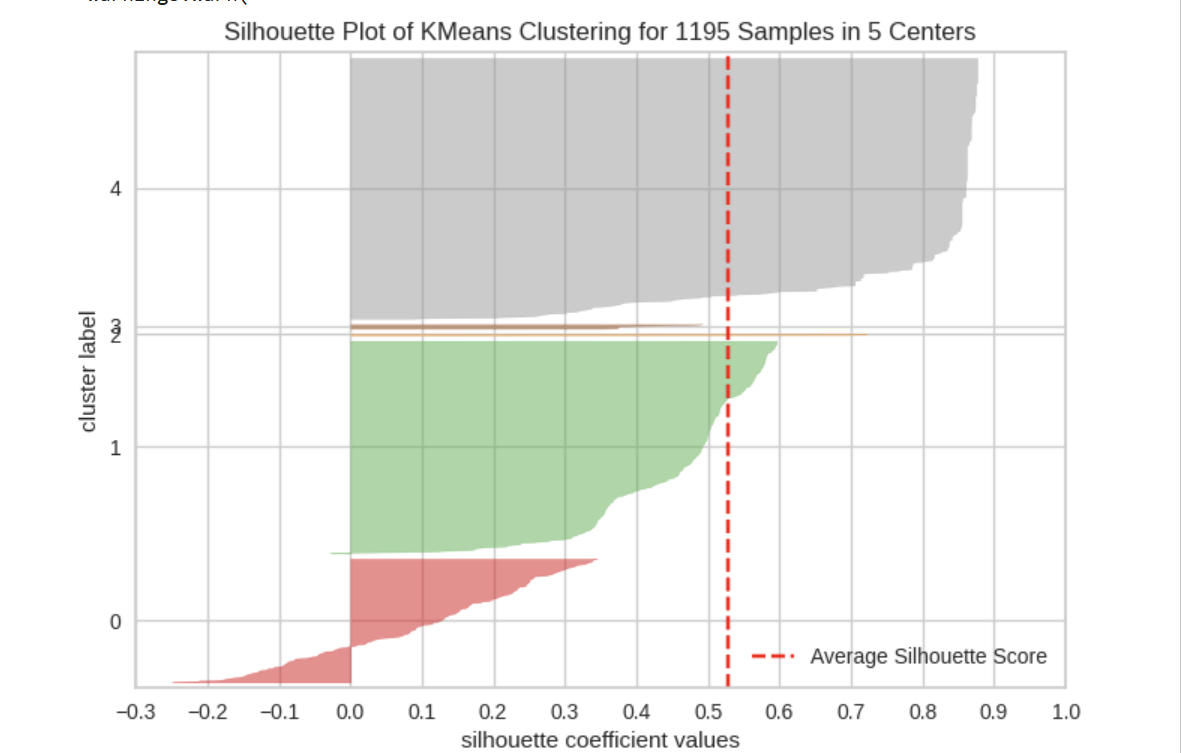

## **Final Clustering Results**
The final clustering results provide meaningful insight into the different productivity patterns among garment factory workers. By analyzing how workers group together based on factors such as idle time, overtime, work-in-progress levels, and targeted productivity, the clustering model highlights clear differences in efficiency, stability, and workflow conditions. These patterns help managers understand which workers consistently perform well, which workers experience productivity challenges, and which cases reflect irregular or special working conditions. Overall, the clustering results offer a practical foundation for making targeted operational improvements, optimizing workflows, and supporting workers based on their specific productivity behaviors.

## **Results Comparison with Selected Research Paper**



*  Our classification findings align with the research paper’s conclusion that decision-tree-based models are effective for predicting garment worker productivity. The paper shows that tree and boosted models capture the key operational factors influencing output, and our results reinforce this by identifying targeted productivity, idle time, and overtime as dominant predictors. This consistency indicates that our model is responding to the same productivity shaping conditions highlighted in the stud
*   Our clustering analysis also supports the paper’s emphasis on uncovering hidden performance patterns among workers. While the paper focuses mostly on prediction, it notes the importance of understanding underlying causes of productivity variation. Our clusters, separating stable high performers, inconsistent workers, and operationally strained groups, provide exactly that deeper insight.



---

## **Summary of Results**



###   **Classification**
The Decision Tree (Entropy, 80/20 split) performed best, giving the most reliable predictions for High, Medium, and Low productivity based on key operational factors like targeted productivity, idle time, and overtime.
###  **Clustering**
K-Means (K = 5) produced clear and meaningful worker groups, reflecting different productivity behaviors and operational conditions across the factory.


## **Technique Comparison**



### Technique Comparison

| Technique      | Best Model                          | Metric              | Key Insight |
|---------------|------------------------------------|---------------------|------------|
| **Classification** | Decision Tree (Entropy, 80/20)     | Accuracy: 77%       | Predicts productivity and highlights the most influential performance factors |
| **Clustering**   | K-Means (K = 5)                   | Silhouette: 0.5288  | Reveals distinct productivity patterns among workers |

# **[8] References**



*   "Scikit-learn Documentation," [Online]. Available: https://scikit-learn.org/stable/. [Accessed: Nov. 17, 2025].

*   "Pandas Documentation," [Online]. Available: https://pandas.pydata.org/. [Accessed: Nov. 19, 2025].
*   "KneeLocator Documentation," [Online]. Available: https://kneed.readthedocs.io/. [Accessed: Nov. 19, 2025].


*  "Yellowbrick Documentation," [Online]. Available: https://www.scikit-yb.org/en/latest/. [Accessed: Nov. 19, 2025].


*   I. A. Siddique, "Productivity Prediction of Garment Employees," Kaggle, 2019. Available: https://www.kaggle.com/datasets/ishadss/productivity-prediction-of-garment-employees. [Accessed: Oct. 26, 2025.]


